# Biologically-plausible learning rules (EIANN) inside a generative cognitive map (GCML)

**Cross-pollinating two 2026 papers.**

| | Paper | What we take from it |
|---|---|---|
| **Paper 1 — the *host*** | Lin, Yang, Zhao, Pezzulo & Maass (2026), *Neural sampling from cognitive maps enables goal-directed imagination and planning*, **Nature Machine Intelligence** 8:1045–1065 · [doi:10.1038/s42256-026-01254-4](https://doi.org/10.1038/s42256-026-01254-4) · code: `LH-cbicr/GCML` | The **model and the tasks**: the generative cognitive map learner (GCML), its grid-cell map, its abstract-graph planning task and its compositional tiling task |
| **Paper 2 — the *donor*** | Galloni, Peddada, Chennawar & Milstein (2026), *Cellular and subcellular specialization enables biology-constrained deep learning*, **Cell Reports** 45:117159 · [doi:10.1016/j.celrep.2026.117159](https://doi.org/10.1016/j.celrep.2026.117159) · code: `Milstein-Lab/EIANN` | The **learning rules**: LDS, temporally-contrastive Hebbian, BCM, normalized Hebbian, Oja, and BTSP |

---

## Why these two models compose so neatly

GCML learns **four linear projections** by *local* online plasticity, and it never
backpropagates:

$$\hat{\mathbf s}_{t+1}=\mathbf{Q}\mathbf o_t+\mathbf{V}\mathbf a_t \qquad
\mathbf u_t=\mathbf W(\mathbf s^{*}-\hat{\mathbf s}_t)\qquad
\hat{\mathbf g}_t=\mathbf G\hat{\mathbf s}_t$$

$$\Delta\mathbf V=\eta_v(\mathbf s_{t+1}-\hat{\mathbf s}_{t+1})\mathbf a_t^{\top}\;(12)\qquad
\Delta\mathbf Q=\eta_q(\hat{\mathbf s}_{t+1}-\mathbf s_{t+1})\mathbf o_t^{\top}\;(13)$$
$$\Delta\mathbf W=\eta_w\mathbf a_t(\mathbf s_{t+1}-\mathbf s_t)^{\top}\;(14)\qquad
\Delta\mathbf G=\eta_g(\mathbf g_t-\mathbf G\mathbf s_t)\mathbf s_t^{\top}\;(17)$$

EIANN's *dendritic target propagation* has exactly the same shape at each synapse.
A postsynaptic unit computes a **dendritic state** $d_i$ (top-down excitation minus
lateral dendritic inhibition), and the bottom-up weights are updated by

$$\Delta w_{ij}=\eta\, d_i\, a_j^{(\text{pre})}\qquad\text{(Eq. 9, the "LDS" rule)}$$

Paper 2's central claim in its Figure 5 is that **once the dendritic state has been
set, *many different* biological plasticity rules can be substituted at that
synapse** — BTSP, temporally-contrastive Hebbian, BCM — and it asks which ones
still descend the error gradient.

So the port is principled rather than cosmetic:

> **Every GCML prediction error plays the role of an EIANN dendritic state.**
> Substituting EIANN's rules for GCML's delta rules is precisely the experiment
> paper 2 runs, transplanted from image classification into planning and
> goal-directed imagination.

### The synapse-level dictionary used throughout this notebook

| GCML matrix | presynaptic rate `pre` | postsynaptic activity `post` | target | dendritic state `delta` |
|---|---|---|---|---|
| $\mathbf V$ (action embedding) | one-hot $\mathbf a_t$ | $\mathbf V\mathbf a_t$ | $\mathbf s_{t+1}-\mathbf s_t$ | $+(\mathbf s_{t+1}-\hat{\mathbf s}_{t+1})$ |
| $\mathbf Q$ (obs. embedding) | one-hot $\mathbf o_{t+1}$ | $\mathbf Q\mathbf o_{t+1}$ | $\hat{\mathbf s}_{t+1}$ | $-(\mathbf s_{t+1}-\hat{\mathbf s}_{t+1})$ |
| $\mathbf W$ (inverse model) | $\Delta\mathbf s=\mathbf s_{t+1}-\mathbf s_t$ | $\mathbf W\Delta\mathbf s$ | one-hot $\mathbf a_t$ | $\mathbf a_t-\mathbf W\Delta\mathbf s$ |
| $\mathbf G$ (affordance gate) | $\mathbf s_t$ | $\mathbf G\mathbf s_t$ | affordance $\mathbf g_t$ | $\mathbf g_t-\mathbf G\mathbf s_t$ |

**A useful consequence:** for a single linear projection, EIANN's LDS rule *is*
GCML's delta rule *is* plain gradient descent on $\tfrac12\lVert\text{target}-\text{post}\rVert^2$.
The baseline is therefore one of the ported rules, which makes the comparison
airtight rather than apples-to-oranges.

---

## What this notebook does

1. Implements **9 plasticity rules** ported from `EIANN/rules/` behind one API.
2. Rebuilds **three GCML tasks** from paper 1 with a swappable rule at every synapse:
   * **A — abstract graph** (paper 1, Figs. 3 & 6a–c): $k$-shortest-path planning by sampling.
   * **B — grid-cell 2D navigation** (paper 1, Fig. 1): imagined trajectories, obstacle detours, generalization to an unexplored quadrant.
   * **C — compositional tiling** (paper 1, Figs. 4–5 & 6d): NP-hard silhouette decomposition, trained on 5 blocks and tested on 8.
3. Runs a **fair per-rule learning-rate search**, then benchmarks every rule on every task over multiple seeds.
4. Reproduces paper 2's diagnostic: the **alignment angle** between each rule's weight update and the gradient.
5. Produces a **cross-task summary** and a discussion of what transfers and what does not.

## 0 · Setup

Everything runs on CPU in a few minutes with `QUICK = True`. Set `QUICK = False`
for the full benchmark (roughly 30–60 min on a Colab CPU; a GPU helps the graph task).

In [ ]:
# Colab has everything we need; these are no-ops on a normal Colab runtime.
try:
    import torch, networkx, sklearn      # noqa
except ImportError:
    !pip -q install torch networkx scikit-learn

import os, math, copy, json, time, itertools, warnings
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx

warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False})

# ---------------------------------------------------------------- experiment size
QUICK = False          # <-- set to False for the full benchmark

CFG = dict(
    seeds        = [0, 1] if QUICK else [0, 1, 2, 3, 4],
    graph_steps  = 800   if QUICK else 2500,
    graph_pairs  = 25    if QUICK else 60,
    graph_samples= 8     if QUICK else 20,
    grid_steps   = 500   if QUICK else 1500,
    grid_explore = 30000 if QUICK else 60000,
    grid_pairs   = 10    if QUICK else 25,
    tile_traj    = 2000  if QUICK else 6000,
    tile_epochs  = 2     if QUICK else 3,
    tile_test    = 50    if QUICK else 150,
)
print("device:", DEVICE, "| QUICK:", QUICK)

device: cpu | QUICK: False


## 1 · The EIANN plasticity-rule library

Ported from `EIANN/rules/{backprop_like,hebbian,btsp}.py`. Every rule exposes the
same three-argument interface `step(pre, post, delta)`, so any rule can be dropped
into any GCML projection.

**Rules included**

| key | EIANN class | consults an error/target? | notes |
|---|---|---|---|
| `LDS` | `BP_like_2L` (Eq. 9) | ✔ | linear dendritic state — identical to GCML's native delta rule |
| `BP-Adam` | backprop reference | ✔ | not biologically plausible; the ML upper bound |
| `Hebb-WN` | `Hebb_WeightNorm_4` (Eqs. 1–3) | ✘ | unsupervised, heterosynaptic L1 renormalization |
| `Hebb-WN-sup` | `Supervised_Hebb_WeightNorm_4` | ✔ | same, but postsynaptic activity nudged to target — *this is paper 1's Eq. 14* |
| `Oja` | `Ojas_rule` | ✘ | self-normalizing PCA |
| `Oja-sup` | `Ojas_rule` + nudge | ✔ | |
| `BCM` | `Supervised_BCM_4` (Eq. 16) | (indirect) | sliding threshold, refers to activity only |
| `TCH` | `Hebbian_Temporal_Contrast` (Eqs. 13–15) | ✔ | contrast between sensory and supervised phases |
| `BTSP` | `BTSP_19` (Eq. 17) | ✔ | saturating weight-dependent one-shot plasticity with second-long eligibility traces |

### Two adaptations that porting BTSP forces on us — and why they are principled

1. **The signed-synapse (Dale's law) constraint comes along for the ride.**
   BTSP is defined for non-negative saturable synapses driven by non-negative rates.
   GCML's embeddings are signed. We therefore split each presynaptic population into
   $[\,\mathrm{relu}(\mathbf p),\ \mathrm{relu}(-\mathbf p)\,]$ and give every
   postsynaptic unit one excitatory and one inhibitory weight bank, both confined to
   $[0,w_{\max}]$. A **positive** plateau drives BTSP at the E bank, a **negative**
   plateau at the I bank. This is exactly paper 2's *signed synapse* constraint, and
   it is the honest way to import the rule.

2. **Divisive normalization of the presynaptic population.** BTSP's eligibility trace
   `ET` and its depression sigmoid `q_dep` are calibrated for ReLU firing rates in
   $[0,1]$. GCML embeddings have an arbitrary scale that also *shrinks by an order of
   magnitude during training*. Without normalization BTSP's depression term swamps
   potentiation and the rule collapses (we measured this). Dividing the presynaptic
   vector by its RMS — a standard, well-documented cortical computation — puts `ET`
   back in the biological range. This turns out to be the single change that makes
   BTSP work here, which is itself a result worth reporting.

In [ ]:
"""
EIANN learning rules (Galloni et al., Cell Reports 2026) ported to the linear
projections of the GCML model (Lin et al., Nature Machine Intelligence 2026).

Every GCML weight matrix (Q, V, W, G) is a single linear projection
        post = M @ pre
trained online from a postsynaptic error signal `delta`.  In the language of
paper 2, `delta` plays the role of the *dendritic state / plateau* of the
postsynaptic unit, and `pre` is the presynaptic firing rate.  Each rule below
converts (pre, post, delta) into a weight update.
"""
import math
import torch


# --------------------------------------------------------------------------- #
#  helpers
# --------------------------------------------------------------------------- #
def scaled_rectified_sigmoid(th, peak, xlim=(0., 1.), ylim=(0., 1.)):
    """EIANN.utils.activations.get_scaled_rectified_sigmoid (verbatim port)."""
    slope = 2. / (peak - th)
    y = lambda x: 1. / (1. + math.exp(-slope * (x - th)))
    start_val, end_val = y(xlim[0]), y(xlim[-1])
    amp = end_val - start_val
    target_amp = ylim[1] - ylim[0]
    return lambda xi: (target_amp / amp) * (
        1. / (1. + torch.exp(-slope * (torch.clamp(xi, xlim[0], xlim[-1]) - th))) - start_val
    ) + ylim[0]


def _outer(delta, pre, mode="batch"):
    """Batched outer product  (B,P)x(B,N) -> (P,N).

    mode="batch"  : average over the batch (dense presynaptic input).
    mode="presyn" : average over the samples in which each presynaptic unit was
                    active.  For one-hot presynaptic codes (the embeddings Q and
                    V) this reproduces the per-column online update of GCML and
                    makes learning rates independent of batch size.
    mode="postsyn": same, per postsynaptic unit.  Appropriate when the
                    postsynaptic target is one-hot over a large action space
                    (the inverse model W of the tiling task), where a batch
                    average would otherwise shrink every row by 1/n_actions.
    """
    num = delta.t() @ pre
    if mode == "presyn":
        den = pre.abs().sum(0).clamp(min=1e-8).unsqueeze(0)
        return num / den
    if mode == "postsyn":
        den = delta.abs().sum(0).clamp(min=1e-8).unsqueeze(1)
        return num / den
    return num / delta.shape[0]


def cosine_angle(a, b, eps=1e-12):
    """Alignment angle in degrees between two weight updates (paper 2, Fig 3g/5e)."""
    a, b = a.flatten(), b.flatten()
    c = torch.dot(a, b) / (a.norm() * b.norm() + eps)
    return torch.rad2deg(torch.acos(torch.clamp(c, -1., 1.))).item()


# --------------------------------------------------------------------------- #
#  base class
# --------------------------------------------------------------------------- #
class PlasticityRule:
    """Base class.  Mirrors EIANN.rules.base_classes.LearningRule."""

    name = "base"
    #  If True the rule keeps its own internal (E/I split) parameterisation and
    #  overrides `expand_pre` / `weight`.
    dale = False

    def __init__(self, post_dim, pre_dim, lr, device="cpu", init_scale=0.1,
                 generator=None, norm="batch", **kw):
        self.post_dim, self.pre_dim = post_dim, pre_dim
        self.lr = lr
        self.device = device
        self.norm = norm
        self.M = init_scale * torch.randn(post_dim, pre_dim, device=device,
                                          generator=generator)
        self.kw = kw

    def _o(self, delta, pre):
        return _outer(delta, pre, self.norm)

    # -- forward ---------------------------------------------------------- #
    def expand_pre(self, pre):
        return pre

    def weight(self):
        """Effective weight matrix used in the forward pass."""
        return self.M

    def forward(self, pre):
        return self.expand_pre(pre) @ self.weight().t()

    # -- learning --------------------------------------------------------- #
    def delta_M(self, pre, post, delta):
        raise NotImplementedError

    def step(self, pre, post, delta):
        pre = self.expand_pre(pre)
        dM = self.delta_M(pre, post, delta)
        self.M += self.lr * dM
        self.post_step()
        return dM

    def post_step(self):
        pass

    # -- introspection ---------------------------------------------------- #
    def gradient_update(self, pre, post, delta):
        """The update backprop/gradient-descent would prescribe (== LDS)."""
        return self._o(delta, self.expand_pre(pre))


# --------------------------------------------------------------------------- #
#  1. LDS  -- "linear dendritic state" (== GCML's native delta rule)
# --------------------------------------------------------------------------- #
class LDS(PlasticityRule):
    """dw_ij = eta * dendritic_state_i * pre_j        (paper 2, Eq. 9)

    For a single linear projection this is *identical* to gradient descent on
    0.5*||target - post||^2, and identical to the delta rules GCML already uses
    for Q, V, W and G (paper 1, Eqs. 12-14, 17).  It is therefore both the
    baseline and one of the ported rules.
    """
    name = "LDS (delta)"

    def delta_M(self, pre, post, delta):
        return self._o(delta, pre)


# --------------------------------------------------------------------------- #
#  2. Backprop reference (SGD / Adam) -- machine-learning upper bound
# --------------------------------------------------------------------------- #
class BackpropAdam(PlasticityRule):
    """Gradient descent with Adam.  Not biologically plausible; used as the
    machine-learning reference point, exactly as in paper 2."""
    name = "Backprop (Adam)"

    def __init__(self, *a, betas=(0.9, 0.999), eps=1e-8, **kw):
        super().__init__(*a, **kw)
        self.m = torch.zeros_like(self.M)
        self.v = torch.zeros_like(self.M)
        self.t = 0
        self.betas, self.eps = betas, eps

    def step(self, pre, post, delta):
        pre = self.expand_pre(pre)
        g = -self._o(delta, pre)                     # gradient of 0.5*||err||^2
        self.t += 1
        b1, b2 = self.betas
        self.m = b1 * self.m + (1 - b1) * g
        self.v = b2 * self.v + (1 - b2) * g * g
        mhat = self.m / (1 - b1 ** self.t)
        vhat = self.v / (1 - b2 ** self.t)
        upd = -mhat / (vhat.sqrt() + self.eps)
        self.M += self.lr * upd
        return upd


# --------------------------------------------------------------------------- #
#  3. Hebbian with weight normalisation  (paper 2, Eqs. 1-3)
# --------------------------------------------------------------------------- #
class HebbWeightNorm(PlasticityRule):
    """dw_ij = eta * post_i * pre_j , followed by row-wise L1 renormalisation
    (heterosynaptic plasticity).  Purely unsupervised: never consults the error.
    """
    name = "Hebbian + WeightNorm"

    def __init__(self, *a, w_norm=1.0, clamp=False, nudge=0.0, **kw):
        super().__init__(*a, **kw)
        self.w_norm = w_norm
        self.clamp = clamp
        self.nudge = nudge      # 0 -> unsupervised; 1 -> post nudged fully to target
        self._normalise()

    def _act(self, x):
        return torch.clamp(x, 0., 1.) if self.clamp else x

    def delta_M(self, pre, post, delta):
        return self._o(self._act(post + self.nudge * delta), self._act(pre))

    def _normalise(self):
        if self.w_norm is None:          # plain Hebbian, no heterosynaptic norm
            return
        s = self.M.abs().sum(dim=1, keepdim=True)
        nz = s.squeeze(1) > 0
        self.M[nz] = self.M[nz] / s[nz] * self.w_norm

    def post_step(self):
        self._normalise()


# --------------------------------------------------------------------------- #
#  4. Oja's rule  (EIANN.rules.hebbian.Ojas_rule)
# --------------------------------------------------------------------------- #
class Oja(PlasticityRule):
    """dw_ij = eta * (post_i * pre_j - post_i^2 * w_ij).  Self-normalising,
    converges to the leading principal subspace of the input.  Unsupervised."""
    name = "Oja"

    def __init__(self, *a, clamp=False, nudge=0.0, **kw):
        super().__init__(*a, **kw)
        self.clamp = clamp
        self.nudge = nudge

    def _act(self, x):
        return torch.clamp(x, 0., 1.) if self.clamp else x

    def delta_M(self, pre, post, delta):
        p, q = self._act(post + self.nudge * delta), self._act(pre)
        hebb = self._o(p, q)
        decay = (p ** 2).mean(dim=0).unsqueeze(1) * self.M
        return hebb - decay


# --------------------------------------------------------------------------- #
#  5. BCM  (paper 2, Eq. 16; EIANN.rules.hebbian.Supervised_BCM_4)
# --------------------------------------------------------------------------- #
class BCM(PlasticityRule):
    """dw_ij = eta * post~_i * (post~_i - theta_i) * pre_j with a sliding
    threshold theta that tracks the recent second moment of activity.
    `post~` is the *nudged* (target-aligned) activity.  Refers to activity only,
    never to an error signal -> expected to align poorly with the gradient."""
    name = "BCM"

    def __init__(self, *a, theta_tau=100., k=1.0, nudge=1.0, **kw):
        super().__init__(*a, **kw)
        self.theta = torch.ones(self.post_dim, device=self.device) * k
        self.theta_tau, self.k, self.nudge = theta_tau, k, nudge

    def delta_M(self, pre, post, delta):
        post_n = post + self.nudge * delta                    # nudged activity
        self._post_n = post_n
        drive = post_n * (post_n - self.theta.unsqueeze(0))
        return self._o(drive, pre)

    def post_step(self):
        self.theta += (-self.theta + (self._post_n ** 2).mean(0) / self.k) / self.theta_tau


# --------------------------------------------------------------------------- #
#  6. Temporally contrastive Hebbian  (paper 2, Eqs. 13-15)
# --------------------------------------------------------------------------- #
class TCH(PlasticityRule):
    """dw_ij = eta * (post~_i * pre~_j - post_i * pre_j).

    Recovers the dendritic error indirectly, from how much somatic activity
    changed after the nudge.  Because the presynaptic activity of a GCML
    projection is an external (sensory / efference-copy) signal that does not
    change between the sensory and supervised phases, this reduces analytically
    to `nudge * LDS` in the un-clamped case -- an exact statement of the
    relationship that paper 2 makes approximately for its recurrent networks.
    Clamping activities to [0,1] (the biological rate range) breaks that
    equivalence and is enabled with `clamp=True`.
    """
    name = "Temporal-contrast Hebbian"

    def __init__(self, *a, nudge=0.5, clamp=False, **kw):
        super().__init__(*a, **kw)
        self.nudge, self.clamp = nudge, clamp

    def _act(self, x):
        return torch.clamp(x, 0., 1.) if self.clamp else x

    def delta_M(self, pre, post, delta):
        post_fwd = self._act(post)
        post_bwd = self._act(post + self.nudge * delta)
        p = self._act(pre)
        return self._o(post_bwd, p) - self._o(post_fwd, p)


# --------------------------------------------------------------------------- #
#  7. BTSP  (paper 2, Eq. 17 & Methods; EIANN.rules.btsp.BTSP_19)
# --------------------------------------------------------------------------- #
class BTSP(PlasticityRule):
    """Behavioral timescale synaptic plasticity.

    BTSP is defined for *non-negative, saturable* synapses driven by
    non-negative presynaptic rates, so porting it also requires importing
    paper 2's *signed-synapse* (Dale's law) constraint.  We therefore split
    every projection into

        pre_ext = [relu(pre), relu(-pre)]          (non-negative rates)
        post    = (M_E - M_I) @ pre_ext ,  M_E, M_I in [0, w_max]

    i.e. each postsynaptic unit reads the presynaptic population through one
    excitatory and one inhibitory pathway, both with non-negative weights.
    A positive plateau (dendritic Ca spike) drives BTSP at the E pathway; a
    negative plateau drives it at the I pathway.

    Core rule (per pathway):
        dw_ij = plateau_i * [ (w_max - w_ij) * ET_j * IS
                              - w_ij * dep_ratio * q_dep(ET_j * IS) ]
    with slowly decaying presynaptic eligibility traces ET and postsynaptic
    instructive signals IS (temporal_discount for the previous sample).
    """
    name = "BTSP"
    dale = True

    def __init__(self, post_dim, pre_dim, lr, device="cpu", init_scale=0.1,
                 generator=None, w_max=2.0, dep_ratio=1.0, dep_th=0.01,
                 dep_width=0.01, temporal_discount=0.25, max_pop_fraction=1.0,
                 stochastic=False, pre_scale=1.0, pre_norm=True, norm="batch", **kw):
        self.post_dim, self.pre_dim = post_dim, pre_dim
        self.lr, self.device = lr, device
        self.norm = norm
        self.w_max = w_max
        self.dep_ratio = dep_ratio
        self.q_dep = scaled_rectified_sigmoid(dep_th, dep_th + dep_width)
        self.temporal_discount = temporal_discount
        self.max_pop_fraction = max_pop_fraction
        self.stochastic = stochastic
        self.pre_scale = pre_scale
        self.pre_norm = pre_norm
        # non-negative E and I weight banks over the doubled presynaptic pop.
        u = torch.rand(post_dim, 2 * pre_dim, device=device, generator=generator)
        self.ME = init_scale * u
        u2 = torch.rand(post_dim, 2 * pre_dim, device=device, generator=generator)
        self.MI = init_scale * u2
        self.past_ET = None
        self.past_plateau = None

    # -- forward ---------------------------------------------------------- #
    def expand_pre(self, pre):
        p = pre
        if self.pre_norm:
            # divisive normalisation of the presynaptic population, so that the
            # eligibility trace ET occupies the [0,1] biological rate range
            # regardless of the (arbitrary) scale of the GCML embeddings.
            rms = p.pow(2).mean(dim=1, keepdim=True).sqrt().clamp(min=1e-8)
            p = p / rms
        p = p * self.pre_scale
        return torch.cat([torch.clamp(p, min=0.), torch.clamp(-p, min=0.)], dim=1)

    def weight(self):
        return self.ME - self.MI

    @property
    def M(self):
        return self.ME - self.MI

    @M.setter
    def M(self, v):                                   # ignored (E/I split)
        pass

    # -- plateau gating --------------------------------------------------- #
    def _plateau(self, delta):
        pl = torch.clamp(delta, -1., 1.)
        if self.max_pop_fraction >= 1.0:
            return pl
        k = max(1, math.ceil(self.max_pop_fraction * self.post_dim))
        out = torch.zeros_like(pl)
        if self.stochastic:
            mask = torch.bernoulli(pl.abs())
            out = pl * mask
        else:
            idx = pl.abs().topk(k, dim=1).indices
            out.scatter_(1, idx, pl.gather(1, idx))
        return out

    def _btsp_term(self, Wbank, ET, IS):
        """IS: (B,P) non-negative instructive signal; ET: (B,N) in [0,1].

        Because (w_max - W) and W do not depend on the sample index, the batch
        mean of the outer products factorises exactly, avoiding a (B,P,N)
        intermediate:
            mean_b[(w_max-W)_ij ET_bj IS_bi] = (w_max-W)_ij * mean_b[IS_bi ET_bj]
        """
        pot = (self.w_max - Wbank) * _outer(IS, ET, self.norm)
        dep = Wbank * self.dep_ratio * _outer(IS, self.q_dep(ET), self.norm)
        return pot - dep

    def step(self, pre, post, delta):
        ET = torch.clamp(self.expand_pre(pre), 0., 1.)
        plateau = self._plateau(delta)
        pos, neg = torch.clamp(plateau, min=0.), torch.clamp(-plateau, min=0.)

        dE = self._btsp_term(self.ME, ET, pos)
        dI = self._btsp_term(self.MI, ET, neg)

        # --- behavioural-timescale (multi-second) terms -------------------- #
        td = self.temporal_discount
        if self.past_ET is not None and self.past_ET.shape == ET.shape:
            pET = self.past_ET * td
            dE = dE + self._btsp_term(self.ME, pET, pos)
            dI = dI + self._btsp_term(self.MI, pET, neg)
        if self.past_plateau is not None and self.past_plateau.shape == plateau.shape:
            ppos = torch.clamp(self.past_plateau, min=0.) * td
            pneg = torch.clamp(-self.past_plateau, min=0.) * td
            dE = dE + self._btsp_term(self.ME, ET, ppos)
            dI = dI + self._btsp_term(self.MI, ET, pneg)

        self.ME = torch.clamp(self.ME + self.lr * dE, 0., self.w_max)
        self.MI = torch.clamp(self.MI + self.lr * dI, 0., self.w_max)
        self.past_ET, self.past_plateau = ET.clone(), plateau.clone()
        return dE - dI


# --------------------------------------------------------------------------- #
#  registry
# --------------------------------------------------------------------------- #
class SupervisedHebbWeightNorm(HebbWeightNorm):
    """EIANN.rules.hebbian.Supervised_Hebb_WeightNorm_4: identical to the
    unsupervised rule except that the postsynaptic activity is first nudged to
    its target by the dendritic state.  This is exactly the "simple Hebbian
    learning rule" that paper 1 uses for its inverse model W (Eq. 14)."""
    name = "Hebbian + WeightNorm (supervised)"

    def __init__(self, *a, nudge=1.0, **kw):
        super().__init__(*a, nudge=nudge, **kw)


class SupervisedOja(Oja):
    name = "Oja (supervised)"

    def __init__(self, *a, nudge=1.0, **kw):
        super().__init__(*a, nudge=nudge, **kw)


RULES = {
    "LDS":        LDS,
    "BP-Adam":    BackpropAdam,
    "Hebb-WN":    HebbWeightNorm,
    "Hebb-WN-sup": SupervisedHebbWeightNorm,
    "Oja":        Oja,
    "Oja-sup":    SupervisedOja,
    "BCM":        BCM,
    "TCH":        TCH,
    "BTSP":       BTSP,
}

#  Rules that consult a target/error signal (paper 2's key distinction)
ERROR_RULES = {"LDS", "BP-Adam", "TCH", "BTSP", "BCM", "Hebb-WN-sup", "Oja-sup"}
UNSUPERVISED_RULES = {"Hebb-WN", "Oja"}

In [ ]:
print("Registered rules:")
for k, c in RULES.items():
    print(f"  {k:14s} {c.name:42s} {'error-driven' if k in ERROR_RULES else 'unsupervised'}")

# --- sanity check: for a single linear projection, LDS == gradient descent ------
torch.manual_seed(0)
pre  = torch.randn(16, 12)
tgt  = torch.randn(16, 5)
lds  = LDS(5, 12, lr=0.0)
post = lds.forward(pre)
Mg   = lds.M.clone().requires_grad_(True)
loss = 0.5 * ((tgt - pre @ Mg.t()) ** 2).sum(1).mean()
loss.backward()
print("\n||LDS update + gradient|| =",
      float((lds.delta_M(pre, post, tgt - post) + Mg.grad).abs().max()),
      "  (0 => LDS is exactly gradient descent, hence exactly GCML's delta rule)")

Registered rules:
  LDS            LDS (delta)                                error-driven
  BP-Adam        Backprop (Adam)                            error-driven
  Hebb-WN        Hebbian + WeightNorm                       unsupervised
  Hebb-WN-sup    Hebbian + WeightNorm (supervised)          error-driven
  Oja            Oja                                        unsupervised
  Oja-sup        Oja (supervised)                           error-driven
  BCM            BCM                                        error-driven
  TCH            Temporal-contrast Hebbian                  error-driven
  BTSP           BTSP                                       error-driven

||LDS update + gradient|| = 0.0   (0 => LDS is exactly gradient descent, hence exactly GCML's delta rule)


### 1.1 · A rule-agnostic way to measure "is this update a gradient?"

Paper 2's key diagnostic (its Figs. 3g and 5e) is the **alignment angle** between the
update a rule prescribes and the update backpropagation prescribes: $0°$ means
identical, $90°$ means orthogonal to the gradient.

We cannot compare weight matrices directly, because BTSP lives in a doubled E/I
parameter space. So we compare updates **functionally**: how each rule changes the
projection's *output* on a fixed probe batch. This is well defined for every rule.

In [ ]:
def alignment_angle(rule_cls, pre, tgt, lr=1e-3, rule_kw=None, seed=0,
                    norm="batch", n_steps=1):
    """Angle (deg) between the output change a rule induces and the one that
    gradient descent (LDS) induces, on the same probe batch."""
    out = {}
    for name, cls in [("ref", LDS), ("test", rule_cls)]:
        g = torch.Generator().manual_seed(seed)
        kw = dict(init_scale=0.1, generator=g, norm=norm)
        if name == "test":
            kw.update(rule_kw or {})
        r = cls(tgt.shape[1], pre.shape[1], lr=lr, **kw)
        before = r.forward(pre).clone()
        for _ in range(n_steps):
            post = r.forward(pre)
            r.step(pre, post, tgt - post)
        out[name] = (r.forward(pre) - before).flatten()
    return cosine_angle(out["test"], out["ref"])


torch.manual_seed(0)
_pre = torch.randn(64, 40)
_tgt = torch.eye(8)[torch.randint(0, 8, (64,))]
print("Alignment with gradient descent on a random linear problem:")
for k, c in RULES.items():
    kw = {"pre_scale": 0.5, "dep_th": 0.2, "dep_width": 0.2} if k == "BTSP" else {}
    print(f"  {k:14s} {alignment_angle(c, _pre, _tgt, rule_kw=kw):6.1f}°")

Alignment with gradient descent on a random linear problem:
  LDS               0.0°
  BP-Adam          33.2°
  Hebb-WN         133.6°
  Hebb-WN-sup      74.4°
  Oja             161.8°
  Oja-sup          62.1°
  BCM              90.0°
  TCH               0.0°
  BTSP             84.5°


---
# 2 · Task A — goal-directed sampling on an abstract graph

*Paper 1, Figs. 3 and 6a–c.* A 32-node random graph is an abstract
problem-solving environment: nodes are states, edges are actions. After a
self-supervised random walk, GCML must *imagine* short paths from an arbitrary
start to an arbitrary goal by iteratively picking the action whose utility
$\mathbf u=\mathbf W(\mathbf s^{*}-\hat{\mathbf s})$ is highest, gated by the
learned affordance $\hat{\mathbf g}=\mathbf G\hat{\mathbf s}$ and perturbed by
Gaussian noise. Noise turns the deterministic CML into a generative model that
samples a *menu* of near-shortest paths.

All four matrices $\mathbf Q,\mathbf V,\mathbf W,\mathbf G$ are plastic here, so
we can swap the rule at any one of them (or all of them).

**Metrics**

* `success` — fraction of sampled imagined trajectories that actually reach the goal when executed in the graph.
* `excess` — mean path length divided by the true shortest-path length, minus 1.
* `Lk_pct` — the $k$-shortest-path score of paper 1 Fig. 6a: percentage by which the sum of the model's best $k{=}5$ proposed paths exceeds $k\times$ the optimum.

> **A note on one hyperparameter.** The original notebook uses $\eta_g=5\times10^{-4}$
> for the affordance matrix, which leaves the affordance read-out at 19% recall.
> We use $\eta_g=10^{-2}$, which drives it to 100% recall and *improves* the GCML
> baseline; the comparison between rules is unaffected either way.

In [ ]:
"""Task A -- goal-directed sampling on an abstract graph (paper 1, Figs. 3 & 6a-c)."""


# The 32-node random graph used in the GCML paper (verbatim from gcml_abstract_graph.ipynb)
PAPER_ADJ = [
    [0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [1,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
    [0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
    [1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,1,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0],
]


class GraphEnv:
    """Abstract problem-solving environment: nodes = states, edges = actions."""

    def __init__(self, adj=None, device="cpu", seed=0):
        self.adj = torch.tensor(PAPER_ADJ if adj is None else adj, dtype=torch.float32)
        self.n_nodes = self.adj.shape[0]
        self.device = device
        self.edges, self.action_index = self._edges_from_adjacency()
        self.n_actions = len(self.edges)
        self.action_to_node = {v: k for k, v in self.action_index.items()}
        self.node_actions = {i: [] for i in range(self.n_nodes)}
        for (a, b), idx in self.action_index.items():
            self.node_actions[a].append(idx)
        self.affordance = torch.zeros(self.n_nodes, self.n_actions, device=device)
        for n, acts in self.node_actions.items():
            self.affordance[n, acts] = 1.
        self.nxg = nx.from_numpy_array(self.adj.numpy())
        self.sp = dict(nx.all_pairs_shortest_path_length(self.nxg))
        g = torch.Generator().manual_seed(seed)
        self.reward = (torch.rand(self.n_nodes, generator=g) * 10).to(device)

    def _edges_from_adjacency(self):
        edges, idx, ai = [], 0, {}
        n = self.n_nodes
        for i in range(n):
            for j in range(i + 1, n):
                if self.adj[i][j] != 0:
                    edges.append((i, j)); ai[(i, j)] = idx; idx += 1
                    edges.append((j, i)); ai[(j, i)] = idx; idx += 1
        return edges, ai

    def random_walk(self, length, rng):
        node = int(rng.integers(self.n_nodes))
        pre, act, nxt = [], [], []
        for _ in range(length):
            nb = torch.nonzero(self.adj[node]).flatten().tolist()
            j = nb[int(rng.integers(len(nb)))]
            pre.append(node); act.append(self.action_index[(node, j)]); nxt.append(j)
            node = j
        return (torch.tensor(pre, device=self.device),
                torch.tensor(act, device=self.device),
                torch.tensor(nxt, device=self.device))


class GCMLGraphAgent:
    """GCML with pluggable EIANN plasticity rules on Q, V, W and G.

    rule_spec maps each matrix name -> (rule_name, kwargs).  Any matrix not
    listed keeps GCML's native delta rule (== the LDS rule of paper 2).
    """

    NATIVE_LR = {"Q": 0.1, "V": 0.01, "W": 0.01, "G": 0.01}

    def __init__(self, env, s_dim=1000, rule_spec=None, lrs=None, device="cpu", seed=0):
        self.env, self.s_dim, self.device = env, s_dim, device
        g = torch.Generator(device=device).manual_seed(seed)
        rule_spec = rule_spec or {}
        lrs = {**self.NATIVE_LR, **(lrs or {})}
        no, na = env.n_nodes, env.n_actions

        def make(key, post_dim, pre_dim, init_scale, norm, **extra):
            name, kw = rule_spec.get(key, ("LDS", {}))
            cls = RULES[name]
            return cls(post_dim, pre_dim, lr=lrs[key], device=device,
                       init_scale=init_scale, generator=g, norm=norm,
                       **{**extra, **kw})

        # Q: s = Q @ onehot(o) ; V: Vs = V @ onehot(a)  -> one-hot presynaptic code
        self.Q = make("Q", s_dim, no, 1.0, "presyn", pre_scale=1.0)
        self.V = make("V", s_dim, na, 0.1, "presyn", pre_scale=1.0)
        # W: utility = W @ ds ; G: affordance = G @ s  -> dense presynaptic code
        self.W = make("W", na, s_dim, 0.1, "batch", pre_scale=0.5, w_max=0.5)
        self.G = make("G", na, s_dim, 0.1, "batch", pre_scale=0.5, w_max=0.5)
        self.eyeO = torch.eye(no, device=device)
        self.eyeA = torch.eye(na, device=device)

    # -- convenience read-outs ------------------------------------------- #
    def embed_obs(self, idx):
        return self.Q.forward(self.eyeO[idx])

    def embed_act(self, idx):
        return self.V.forward(self.eyeA[idx])

    # -- one online learning step ---------------------------------------- #
    def learn(self, o_pre, action, o_next):
        oh_o_next = self.eyeO[o_next]
        oh_a = self.eyeA[action]
        s_pre = self.embed_obs(o_pre)
        s_next = self.embed_obs(o_next)
        s_pred = s_pre + self.embed_act(action)
        pred_err = s_next - s_pred                       # dendritic state
        ds = s_next - s_pre

        # V : post = V a , target = ds            -> delta = +pred_err
        self.V.step(oh_a, self.embed_act(action), pred_err)
        # Q : post = Q o_next , target = s_pred   -> delta = -pred_err
        self.Q.step(oh_o_next, s_next, -pred_err)
        # W : post = W ds , target = onehot(a)    (inverse model)
        u = self.W.forward(ds)
        self.W.step(ds, u, oh_a - u)
        # G : post = G s_pre , target = affordance(o_pre)
        aff = self.env.affordance[o_pre]
        gh = self.G.forward(s_pre)
        self.G.step(s_pre, gh, aff - gh)

        return dict(pred=float((pred_err ** 2).mean()),
                    inv=float(((oh_a - u) ** 2).mean()),
                    aff=float(((aff - gh) ** 2).mean()))

    # -- goal-directed sampling (imagination) ---------------------------- #
    @torch.no_grad()
    def sample_trajectory(self, start, goal, sigma=0.15, max_len=40,
                          affordance="learned", generator=None):
        env = self.env
        s_star = self.embed_obs(torch.tensor([goal], device=self.device))
        s_hat = self.embed_obs(torch.tensor([start], device=self.device)).clone()
        node, path, actions, used = start, [start], [], []
        for t in range(max_len):
            u = self.W.forward(s_star - s_hat)               # utility (1, n_a)
            if sigma > 0:
                scale = u.max().clamp(min=1e-8)
                u = u + torch.randn(u.shape, device=self.device,
                                    generator=generator) * scale * sigma
            if affordance == "true" or t == 0:
                gate = env.affordance[node].unsqueeze(0).clone()
            else:
                gate = self.G.forward(s_hat).clamp(min=0.)
            gate = gate.clone()
            if used:
                gate[0, used] = 0.
            e = u * gate
            if float(e.max()) <= 0:                          # no eligible action
                legal = [a for a in env.node_actions[node] if a not in used]
                if not legal:
                    break
                a_idx = int(np.random.choice(legal))
            else:
                a_idx = int(torch.argmax(e))
            # execute in the real graph if legal, otherwise the plan fails here
            src, dst = env.action_to_node[a_idx]
            if src != node:
                break
            actions.append(a_idx); used.append(a_idx)
            s_hat = s_hat + self.embed_act(torch.tensor([a_idx], device=self.device))
            node = dst; path.append(node)
            if node == goal:
                return path, actions, True
        return path, actions, False


# --------------------------------------------------------------------------- #
#  training / evaluation
# --------------------------------------------------------------------------- #
def train_graph_agent(agent, env, n_steps=2000, walk_len=127, seed=0, log_every=100):
    rng = np.random.default_rng(seed)
    hist = {"pred": [], "inv": [], "aff": []}
    for it in range(n_steps):
        o_pre, act, o_next = env.random_walk(walk_len, rng)
        losses = agent.learn(o_pre, act, o_next)
        for k, v in losses.items():
            hist[k].append(v)
    return hist


@torch.no_grad()
def evaluate_graph(agent, env, n_pairs=60, n_samples=20, sigma=0.15, seed=0,
                   max_len=40, affordance="learned"):
    """Success rate, path-length excess and k-shortest-path quality."""
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=agent.device).manual_seed(seed)
    succ, excess, lk = [], [], []
    n = env.n_nodes
    for _ in range(n_pairs):
        s, g = rng.integers(n), rng.integers(n)
        while g == s or env.sp[int(s)].get(int(g)) is None:
            s, g = rng.integers(n), rng.integers(n)
        d = env.sp[int(s)][int(g)]
        lens = []
        for _ in range(n_samples):
            path, _, ok = agent.sample_trajectory(int(s), int(g), sigma=sigma,
                                                  max_len=max_len, generator=gen,
                                                  affordance=affordance)
            if ok:
                lens.append(len(path) - 1)
        succ.append(len(lens) / n_samples)
        if lens:
            excess.append(np.mean(lens) / d - 1.)
            k = min(5, len(lens))
            best_k = sorted(lens)[:k]
            lk.append((sum(best_k) / (k * d) - 1.) * 100.)
    return dict(success=float(np.mean(succ)),
                excess=float(np.mean(excess)) if excess else float("nan"),
                Lk_pct=float(np.mean(lk)) if lk else float("nan"))


@torch.no_grad()
def reward_vs_noise(agent, env, start, goal, sigmas, n_traj=40, n_rep=20, seed=0):
    """Paper 1, Fig. 3f: best reward collected among n_traj sampled solutions."""
    out = {}
    for sig in sigmas:
        best = []
        for r in range(n_rep):
            gen = torch.Generator(device=agent.device).manual_seed(seed + r)
            vals = []
            for _ in range(n_traj):
                path, _, ok = agent.sample_trajectory(start, goal, sigma=sig,
                                                      max_len=40, generator=gen)
                if ok:
                    vals.append(float(env.reward[path].sum()) - 5. * (len(path) - 1))
            best.append(max(vals) if vals else float("nan"))
        out[sig] = (float(np.nanmean(best)), float(np.nanstd(best)))
    return out

32 nodes, 96 directed actions (mean degree 3.0)
trained in 15s


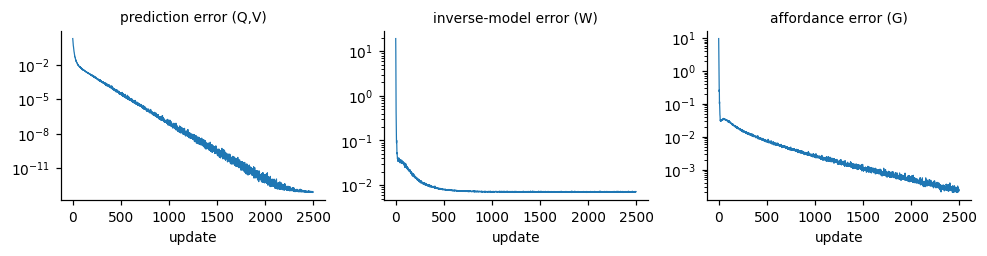

sigma=0.0    success=1.000  excess=+0.037  L_k=3.8%
sigma=0.15   success=1.000  excess=+0.125  L_k=0.7%
sigma=0.25   success=0.990  excess=+0.322  L_k=1.0%


In [ ]:
env_graph = GraphEnv(seed=0, device=DEVICE)
print(f"{env_graph.n_nodes} nodes, {env_graph.n_actions} directed actions "
      f"(mean degree {float(env_graph.adj.sum(1).mean()):.1f})")

# --- the GCML baseline (native delta rules everywhere) --------------------------
t0 = time.time()
base = GCMLGraphAgent(env_graph, s_dim=1000, seed=0, device=DEVICE)
hist = train_graph_agent(base, env_graph, n_steps=CFG["graph_steps"], seed=1)
print(f"trained in {time.time()-t0:.0f}s")

fig, ax = plt.subplots(1, 3, figsize=(9, 2.4))
for a, (k, lab) in zip(ax, [("pred", "prediction error (Q,V)"),
                            ("inv", "inverse-model error (W)"),
                            ("aff", "affordance error (G)")]):
    a.plot(hist[k], lw=.8); a.set_yscale("log"); a.set_title(lab, fontsize=9)
    a.set_xlabel("update")
plt.tight_layout(); plt.show()

for sig in (0.0, 0.15, 0.25):
    r = evaluate_graph(base, env_graph, n_pairs=CFG["graph_pairs"],
                       n_samples=CFG["graph_samples"], sigma=sig, seed=3)
    print(f"sigma={sig:<5}  success={r['success']:.3f}  excess={r['excess']:+.3f}  "
          f"L_k={r['Lk_pct']:.1f}%")

### 2.1 · The learned cognitive map

A 2-D projection of the columns of $\mathbf{Q}$ recovers paper 1's Fig. 3b: the
geometry of the embedding gives a *sense of direction*, so that from any node the
edge pointing "towards" the goal in embedding space is the right one to take.

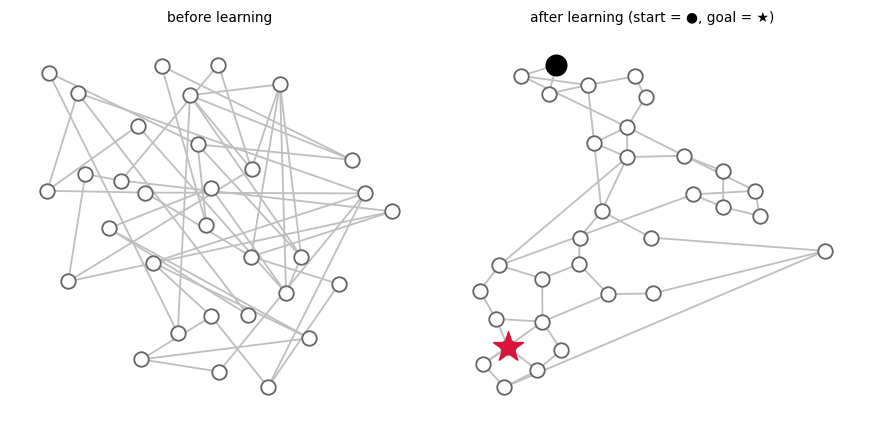

In [ ]:
from sklearn.manifold import TSNE

def plot_cognitive_map(agent, env, start=None, goal=None, seed=0, ax=None,
                       title=""):
    Qd = agent.Q.M.detach().cpu().numpy().T if not agent.Q.dale else \
         agent.embed_obs(torch.arange(env.n_nodes, device=agent.device)).cpu().numpy()
    xy = TSNE(2, perplexity=8, init="pca", learning_rate=200,
              random_state=seed).fit_transform(Qd.astype(float))
    G = nx.from_numpy_array(env.adj.cpu().numpy())
    pos = {i: xy[i] for i in range(env.n_nodes)}
    ax = ax or plt.gca()
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="0.75", width=1.2)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color="white", edgecolors="0.4",
                           node_size=90, linewidths=1.2)
    if start is not None:
        nx.draw_networkx_nodes(G, pos, nodelist=[start], ax=ax, node_color="k",
                               node_size=180)
    if goal is not None:
        nx.draw_networkx_nodes(G, pos, nodelist=[goal], ax=ax, node_color="crimson",
                               node_shape="*", node_size=420)
    ax.set_title(title, fontsize=9); ax.axis("off")

untrained = GCMLGraphAgent(env_graph, s_dim=1000, seed=0, device=DEVICE)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
plot_cognitive_map(untrained, env_graph, ax=ax[0], title="before learning")
plot_cognitive_map(base, env_graph, start=26, goal=1, ax=ax[1],
                   title="after learning (start = ●, goal = ★)")
plt.tight_layout(); plt.show()

### 2.2 · Fair per-rule learning-rate search

Different plasticity rules have completely different natural weight-update
magnitudes, so comparing them at one shared learning rate would be meaningless.
Paper 2 addressed this with a 30,000-variant hyperparameter search per network.
We do a small, explicit, logarithmic search per rule and always report the
**best** setting each rule achieves — the comparison is therefore generous to
every rule.

In [ ]:
# Rule-specific search grids and any fixed rule hyperparameters.
GRAPH_GRID = {
    "LDS":         (dict(),                                                        [3e-3, 1e-2, 3e-2]),
    "BP-Adam":     (dict(),                                                        [1e-3, 3e-3, 1e-2]),
    "TCH":         (dict(nudge=0.5),                                               [1e-2, 3e-2, 1e-1]),
    "BCM":         (dict(theta_tau=100., k=1.0),                                   [3e-3, 3e-2, 1e-1]),
    "BTSP":        (dict(pre_scale=0.5, dep_th=0.2, dep_width=0.2, w_max=0.5),     [5e-2, 1.5e-1, 5e-1]),
    "Hebb-WN-sup": (dict(w_norm=1.0),                                              [1e-2, 1e-1, 1.0]),
    "Hebb-WN":     (dict(w_norm=1.0),                                              [1e-3, 1e-2, 1e-1]),
    "Oja-sup":     (dict(),                                                        [3e-4, 3e-3, 3e-2]),
    "Oja":         (dict(),                                                        [3e-4, 3e-3, 3e-2]),
}

def run_graph(rule, lr, kw, seed, steps, target="W", eval_kw=None):
    ag = GCMLGraphAgent(env_graph, s_dim=1000, seed=seed, device=DEVICE,
                        rule_spec={target: (rule, kw)}, lrs={target: lr})
    train_graph_agent(ag, env_graph, n_steps=steps, seed=seed + 100)
    r = evaluate_graph(ag, env_graph, sigma=0.15, seed=seed + 200,
                       **(eval_kw or dict(n_pairs=CFG["graph_pairs"],
                                          n_samples=CFG["graph_samples"])))
    return ag, r


def search_lr(runner, grid, seed=0, key="success", **kw):
    """Pick, per rule, the learning rate that maximises `key`."""
    best = {}
    for rule, (rkw, lrs) in grid.items():
        rows = []
        for lr in lrs:
            try:
                _, r = runner(rule, lr, rkw, seed, **kw)
            except Exception as e:
                r = {key: float("nan")}
            rows.append((lr, r))
        lr, r = max(rows, key=lambda x: (x[1][key] if x[1][key] == x[1][key] else -1))
        best[rule] = dict(lr=lr, **r)
        print(f"  {rule:12s} best lr={lr:<8g} {key}={r[key]:.3f}")
    return best

print("Learning-rate search on task A (inverse model W):")
t0 = time.time()
GRAPH_BEST_LR = search_lr(run_graph, GRAPH_GRID, seed=0,
                          steps=max(400, CFG["graph_steps"] // 2),
                          eval_kw=dict(n_pairs=15, n_samples=5))
print(f"({time.time()-t0:.0f}s)")

Learning-rate search on task A (inverse model W):
  LDS          best lr=0.01     success=1.000
  BP-Adam      best lr=0.003    success=1.000
  TCH          best lr=0.01     success=1.000
  BCM          best lr=0.1      success=1.000
  BTSP         best lr=0.15     success=1.000
  Hebb-WN-sup  best lr=0.01     success=1.000
  Hebb-WN      best lr=0.01     success=0.120
  Oja-sup      best lr=0.03     success=1.000
  Oja          best lr=0.003    success=0.027
(316s)


### 2.3 · Experiment A1 — swap the rule at the inverse model $\mathbf W$

$\mathbf W$ is the component that actually *chooses actions*: it maps a state
difference onto the action that would cause it, and paper 1 applies it far
out-of-distribution, to the large difference $\mathbf s^{*}-\hat{\mathbf s}$
between a distant goal and the current imagined state. Swapping the rule here
isolates the effect of plasticity on the planner while leaving the cognitive map
itself intact.

In [ ]:
def bench_graph(target="W", seeds=None, steps=None, sigmas=(0.0, 0.15, 0.25)):
    seeds = seeds or CFG["seeds"]; steps = steps or CFG["graph_steps"]
    res = {}
    for rule, (kw, _) in GRAPH_GRID.items():
        lr = GRAPH_BEST_LR[rule]["lr"]
        per = {s: [] for s in sigmas}
        angles = []
        for sd in seeds:
            ag = GCMLGraphAgent(env_graph, s_dim=1000, seed=sd, device=DEVICE,
                                rule_spec={target: (rule, kw)}, lrs={target: lr})
            train_graph_agent(ag, env_graph, n_steps=steps, seed=sd + 100)
            for sg in sigmas:
                per[sg].append(evaluate_graph(ag, env_graph, sigma=sg,
                                              n_pairs=CFG["graph_pairs"],
                                              n_samples=CFG["graph_samples"],
                                              seed=sd + 200))
            angles.append(measure_graph_alignment(ag, env_graph, rule, kw, lr, sd))
        res[rule] = dict(lr=lr, angle=float(np.nanmean(angles)),
                         **{f"{k}@{sg}": float(np.mean([p[k] for p in per[sg]]))
                            for sg in sigmas for k in ("success", "excess", "Lk_pct")},
                         **{f"{k}@{sg}_sd": float(np.std([p[k] for p in per[sg]]))
                            for sg in sigmas for k in ("success",)})
        print(f"  {rule:12s} succ={res[rule]['success@0.15']:.3f}  "
              f"excess={res[rule]['excess@0.15']:+.3f}  "
              f"L_k={res[rule]['Lk_pct@0.15']:5.1f}%  angle={res[rule]['angle']:5.1f}deg")
    return res


def measure_graph_alignment(agent, env, rule, kw, lr, seed):
    """Angle between this rule's W-update and the gradient, on real GCML data."""
    rng = np.random.default_rng(seed + 999)
    o, a, n = env.random_walk(128, rng)
    ds = (agent.embed_obs(n) - agent.embed_obs(o)).detach()
    tgt = torch.eye(env.n_actions, device=agent.device)[a]
    return alignment_angle(RULES[rule], ds, tgt, lr=lr, rule_kw=kw, seed=seed,
                           norm="batch", n_steps=3)


print("Task A1 - rule swapped at W:")
t0 = time.time(); RES_A1 = bench_graph("W"); print(f"({time.time()-t0:.0f}s)")

Task A1 - rule swapped at W:
  LDS          succ=0.999  excess=+0.133  L_k=  0.6%  angle=  0.0deg
  BP-Adam      succ=0.998  excess=+0.215  L_k=  3.9%  angle= 16.5deg
  TCH          succ=0.999  excess=+0.124  L_k=  0.4%  angle=  0.3deg
  BCM          succ=1.000  excess=+0.079  L_k=  0.6%  angle= 84.2deg
  BTSP         succ=0.999  excess=+0.056  L_k=  0.6%  angle= 90.4deg
  Hebb-WN-sup  succ=1.000  excess=+0.059  L_k=  0.4%  angle= 84.2deg
  Hebb-WN      succ=0.098  excess=+0.815  L_k= 69.4%  angle=173.5deg
  Oja-sup      succ=1.000  excess=+0.080  L_k=  0.7%  angle= 82.0deg
  Oja          succ=0.078  excess=+1.038  L_k= 89.7%  angle=172.1deg
(1271s)


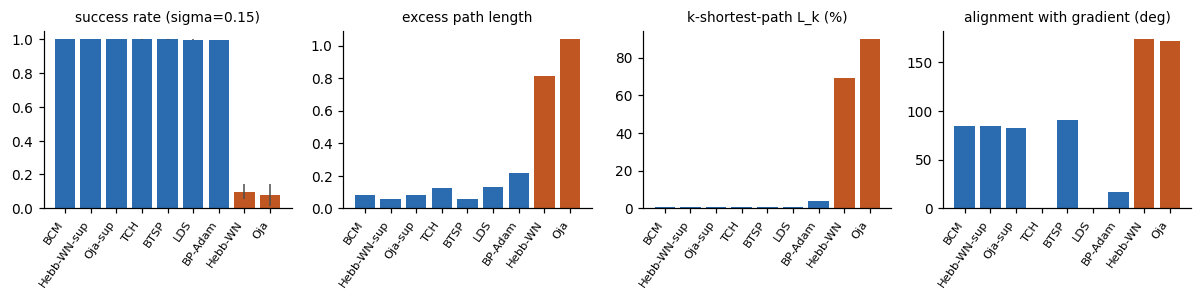

blue = rule consults a target/error signal   orange = purely unsupervised


In [ ]:
def bar_panel(res, keys, labels, order=None, figsize=(11, 2.8), ref=None):
    order = order or sorted(res, key=lambda r: -res[r].get(keys[0], 0))
    fig, axes = plt.subplots(1, len(keys), figsize=figsize)
    for ax, k, lab in zip(np.atleast_1d(axes), keys, labels):
        vals = [res[r].get(k, np.nan) for r in order]
        cols = ["#2b6cb0" if r in ERROR_RULES else "#c05621" for r in order]
        ax.bar(range(len(order)), vals, color=cols)
        sd = [res[r].get(k + "_sd", 0) for r in order]
        if any(sd):
            ax.errorbar(range(len(order)), vals, yerr=sd, fmt="none", ecolor="0.3", lw=1)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, rotation=55, ha="right", fontsize=7.5)
        ax.set_title(lab, fontsize=9)
        if ref is not None and k in ref:
            ax.axhline(ref[k], ls="--", c="k", lw=1)
    plt.tight_layout(); plt.show()
    return order

ORDER_A = bar_panel(RES_A1,
    ["success@0.15", "excess@0.15", "Lk_pct@0.15", "angle"],
    ["success rate (sigma=0.15)", "excess path length", "k-shortest-path L_k (%)",
     "alignment with gradient (deg)"])
print("blue = rule consults a target/error signal   orange = purely unsupervised")

### 2.4 · Diversity is the point: reward collection versus noise

Paper 1's Fig. 3f argues that the *value* of a generative planner is that higher
noise yields a broader menu of near-optimal solutions, so a downstream evaluator
can pick the one that collects the most reward. We reproduce that curve for the
rules that produce a usable inverse model — this tests something the raw success
rate does not: whether a rule preserves a *well-ordered* utility landscape, not
just a correct argmax.

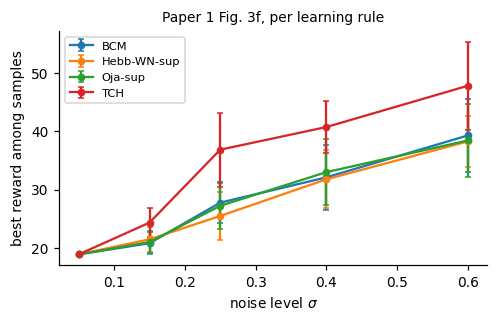

In [ ]:
SIGMAS = [0.05, 0.15, 0.25, 0.4, 0.6]
TOP = [r for r in ORDER_A if RES_A1[r]["success@0.15"] > 0.5][:4]

fig, ax = plt.subplots(figsize=(4.6, 3))
for rule in TOP:
    kw, lr = GRAPH_GRID[rule][0], GRAPH_BEST_LR[rule]["lr"]
    ag = GCMLGraphAgent(env_graph, s_dim=1000, seed=0, device=DEVICE,
                        rule_spec={"W": (rule, kw)}, lrs={"W": lr})
    train_graph_agent(ag, env_graph, n_steps=CFG["graph_steps"], seed=100)
    rv = reward_vs_noise(ag, env_graph, 26, 1, SIGMAS,
                         n_traj=20 if QUICK else 40, n_rep=5 if QUICK else 20)
    m = [rv[s][0] for s in SIGMAS]; e = [rv[s][1] for s in SIGMAS]
    ax.errorbar(SIGMAS, m, yerr=e, marker="o", ms=4, capsize=2, label=rule)
ax.set_xlabel("noise level $\\sigma$"); ax.set_ylabel("best reward among samples")
ax.legend(fontsize=7.5); ax.set_title("Paper 1 Fig. 3f, per learning rule", fontsize=9)
plt.tight_layout(); plt.show()

### 2.5 · Experiment A2 — the full port: every matrix learned by the same rule

Here $\mathbf Q,\mathbf V,\mathbf W$ *and* $\mathbf G$ all use the transplanted
rule. This is much harder: the cognitive map itself must now be built by the
biological rule, and errors compound, because a badly-shaped $\mathbf Q$ makes
the inverse-model problem ill-posed.

Task A2 - rule swapped at Q, V, W and G simultaneously:
  LDS          succ=0.999
  BP-Adam      succ=0.996
  TCH          succ=0.999
  BCM          succ=0.000
  BTSP         succ=0.680
  Hebb-WN-sup  succ=0.049
  Hebb-WN      succ=0.033
  Oja-sup      succ=0.039
  Oja          succ=0.000
(2031s)


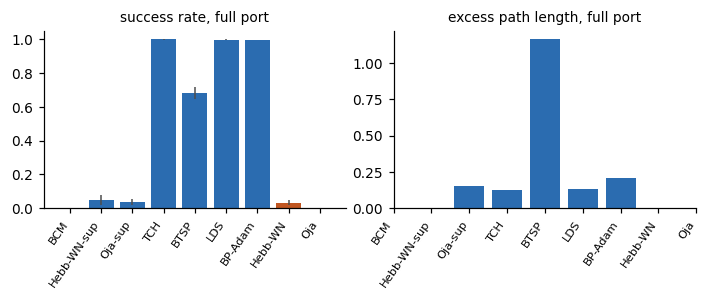

['BCM',
 'Hebb-WN-sup',
 'Oja-sup',
 'TCH',
 'BTSP',
 'LDS',
 'BP-Adam',
 'Hebb-WN',
 'Oja']

In [ ]:
def bench_graph_full(seeds=None, steps=None):
    seeds = seeds or CFG["seeds"]; steps = steps or CFG["graph_steps"]
    res = {}
    for rule, (kw, _) in GRAPH_GRID.items():
        lr = GRAPH_BEST_LR[rule]["lr"]
        acc = []
        for sd in seeds:
            spec = {m: (rule, kw) for m in ("Q", "V", "W", "G")}
            lrs = {"Q": lr * 10, "V": lr, "W": lr, "G": lr}
            try:
                ag = GCMLGraphAgent(env_graph, s_dim=1000, seed=sd, device=DEVICE,
                                    rule_spec=spec, lrs=lrs)
                train_graph_agent(ag, env_graph, n_steps=steps, seed=sd + 100)
                acc.append(evaluate_graph(ag, env_graph, sigma=0.15,
                                          n_pairs=CFG["graph_pairs"],
                                          n_samples=CFG["graph_samples"], seed=sd + 200))
            except Exception:
                acc.append(dict(success=0., excess=float("nan"), Lk_pct=float("nan")))
        res[rule] = {f"{k}@0.15": float(np.nanmean([a[k] for a in acc]))
                     for k in ("success", "excess", "Lk_pct")}
        res[rule]["success@0.15_sd"] = float(np.std([a["success"] for a in acc]))
        print(f"  {rule:12s} succ={res[rule]['success@0.15']:.3f}")
    return res

print("Task A2 - rule swapped at Q, V, W and G simultaneously:")
t0 = time.time(); RES_A2 = bench_graph_full(); print(f"({time.time()-t0:.0f}s)")

bar_panel(RES_A2, ["success@0.15", "excess@0.15"],
          ["success rate, full port", "excess path length, full port"],
          order=ORDER_A, figsize=(6.5, 2.8))

---
# 3 · Task B — imagined 2D trajectories from a grid-cell map

*Paper 1, Fig. 1.* Grid-cell firing is the analytic path-integration model of the
paper: 1000 cells, each a sum of three planar cosine gratings 60° apart, with
scale $\lambda\sim U(0.05, 8)$; the largest-scale 10% span a locally flat 2-D
manifold. Only the **inverse model $\mathbf W$** (4 × n_grid) is plastic — it
learns during exploration to map a change in grid-cell state onto the movement
command that caused it.

Two features of the paper's setup make this a genuinely different test from
Task A:

* **The lower-left quadrant is never visited during exploration** (paper 1, Fig. 1c).
  A good inverse model must nevertheless generate imagined trajectories *through*
  it, because the linearity of $\mathbf W$ extrapolates. This is a direct test of
  whether a plasticity rule preserves that linearity.
* **Noise level controls trajectory diversity** (paper 1, Fig. 1d), so we can ask
  whether a rule produces a utility landscape that degrades *gracefully* under noise.

In [ ]:
"""Task B -- goal-directed imagination of 2D trajectories from a grid-cell map
(paper 1, Fig. 1).  Only the inverse model W (4 x n_grid) is plastic; the grid
code itself is the analytic path-integration model of the paper."""


ARENA = 4.0


# --------------------------------------------------------------------------- #
#  grid-cell population (paper 1, Methods: r(x) = sum_j (1 + cos(k_j.x + phi_j)))
# --------------------------------------------------------------------------- #
class GridCode:
    def __init__(self, n_cells=1000, top_frac=0.10, arena=ARENA, seed=0, device="cpu"):
        rng = np.random.default_rng(seed)
        scales = rng.uniform(0.05, 8.0, n_cells)
        # keep the largest-scale cells: their interference pattern is locally flat
        thr = np.quantile(scales, 1. - top_frac)
        keep = np.where(scales >= thr)[0]
        self.n = len(keep)
        sc = scales[keep]
        theta0 = rng.uniform(0, 2 * np.pi, self.n)
        phases = rng.uniform(0, 2 * np.pi, (self.n, 3))
        angs = theta0[:, None] + np.arange(3)[None, :] * np.pi / 3.
        kmag = (2 * np.pi / sc)[:, None]
        self.kx = torch.tensor(kmag * np.cos(angs), dtype=torch.float32, device=device)
        self.ky = torch.tensor(kmag * np.sin(angs), dtype=torch.float32, device=device)
        self.phi = torch.tensor(phases, dtype=torch.float32, device=device)
        self.device = device
        self.arena = arena

    def __call__(self, xy):
        """xy: (B,2) -> (B, n_cells) firing rates."""
        if xy.dim() == 1:
            xy = xy.unsqueeze(0)
        proj = xy[:, 0:1, None] * self.kx[None] + xy[:, 1:2, None] * self.ky[None]
        return (1. + torch.cos(proj + self.phi[None])).sum(-1)


# --------------------------------------------------------------------------- #
#  exploration: 3 quadrants only (the lower-left quadrant is never visited)
# --------------------------------------------------------------------------- #
def explore(n_steps=50000, dt=0.05, speed=0.5, turn_noise=0.1, forbid=True,
            seed=0, arena=ARENA):
    rng = np.random.default_rng(seed)

    def valid(p):
        if not (0 <= p[0] <= arena and 0 <= p[1] <= arena):
            return False
        if forbid and p[0] < arena / 2 and p[1] < arena / 2:
            return False
        return True

    pos = np.array([rng.uniform(2, 4), rng.uniform(2, 4)])
    ang = rng.uniform(0, 2 * np.pi)
    P, Vel = [], []
    for _ in range(n_steps):
        ang += rng.normal() * turn_noise
        v = speed * np.array([np.cos(ang), np.sin(ang)])
        new = pos + v * dt
        if valid(new):
            P.append(pos.copy()); Vel.append(v.copy()); pos = new
        else:
            ang = rng.uniform(0, 2 * np.pi)
    return np.array(P), np.array(Vel)


def velocity_to_action(v):
    """4 basis action neurons [up, down, left, right] with unit total drive."""
    vx, vy = v[:, 0], v[:, 1]
    a = np.stack([np.maximum(vy, 0), np.maximum(-vy, 0),
                  np.maximum(-vx, 0), np.maximum(vx, 0)], 1)
    return a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-9)


# --------------------------------------------------------------------------- #
#  inverse model
# --------------------------------------------------------------------------- #
def train_inverse_model(grid, rule_name="LDS", lr=1e-3, rule_kw=None, n_steps=400,
                        batch=256, seed=0, device="cpu", data=None):
    P, V = data if data is not None else explore(seed=seed)
    A = velocity_to_action(V)
    xy = torch.tensor(P, dtype=torch.float32, device=device)
    act = torch.tensor(A, dtype=torch.float32, device=device)
    S = grid(xy)

    g = torch.Generator(device=device).manual_seed(seed)
    W = RULES[rule_name](4, grid.n, lr=lr, device=device, init_scale=0.01,
                         generator=g, norm="batch",
                         **{**dict(pre_scale=1.0, w_max=0.5), **(rule_kw or {})})
    rng = np.random.default_rng(seed + 1)
    loss = []
    for it in range(n_steps):
        idx = rng.integers(0, len(P) - 1, batch)
        ds = S[idx + 1] - S[idx]
        tgt = act[idx]
        u = W.forward(ds)
        W.step(ds, u, tgt - u)
        loss.append(float(((tgt - u) ** 2).mean()))
    return W, loss


# --------------------------------------------------------------------------- #
#  goal-directed sampling of imagined trajectories (paper 1, Eq. 3)
# --------------------------------------------------------------------------- #
@torch.no_grad()
def imagine(grid, W, start, goal, sigma=0.3, eta_a=0.05, max_steps=600,
            tol=0.15, walls=(), gamma=0.2, device="cpu", generator=None,
            arena=ARENA):
    goal_s = grid(torch.tensor([goal], dtype=torch.float32, device=device))
    p = np.array(start, dtype=float)
    path = [p.copy()]
    for _ in range(max_steps):
        s = grid(torch.tensor([p], dtype=torch.float32, device=device))
        a = W.forward(goal_s - s)[0]
        if sigma > 0:
            # noise scaled to the magnitude of the utility vector, so that a
            # given sigma means the same thing for every learning rule
            a = a + torch.randn(4, device=device, generator=generator) * sigma * a.abs().max()
        step = np.array([float(a[3] - a[2]), float(a[0] - a[1])])
        n = np.linalg.norm(step)
        step = step / n * eta_a if n > 1e-9 else np.zeros(2)
        # object / barrier cells -> repulsive forces (paper 1, Eq. 6-7)
        for w in walls:
            for q in w:
                d = p - np.array(q)
                r2 = max(float(d @ d), 1e-3)
                step = step + gamma * eta_a * d / r2
        p = np.clip(p + step, 0., arena)
        path.append(p.copy())
        if np.linalg.norm(p - np.array(goal)) < tol:
            return np.array(path), True
    return np.array(path), False


@torch.no_grad()
def evaluate_grid(grid, W, sigma=0.3, n_pairs=20, n_samples=5, seed=0,
                  device="cpu", arena=ARENA):
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=device).manual_seed(seed)
    succ, eff, unexp, div = [], [], [], []
    for _ in range(n_pairs):
        start = rng.uniform(0.3, arena - 0.3, 2)
        goal = rng.uniform(0.3, arena - 0.3, 2)
        while np.linalg.norm(start - goal) < 1.5:
            goal = rng.uniform(0.3, arena - 0.3, 2)
        d0 = np.linalg.norm(start - goal)
        paths, ok_n = [], 0
        for _ in range(n_samples):
            path, ok = imagine(grid, W, start, goal, sigma=sigma, device=device,
                               generator=gen, arena=arena)
            paths.append(path)
            if ok:
                ok_n += 1
                L = np.linalg.norm(np.diff(path, axis=0), axis=1).sum()
                eff.append(d0 / max(L, 1e-9))
                q = path[(path[:, 0] < arena / 2) & (path[:, 1] < arena / 2)]
                unexp.append(len(q) / len(path))
        succ.append(ok_n / n_samples)
        # trajectory diversity: mean pairwise distance between resampled paths
        m = min(len(p) for p in paths)
        if len(paths) > 1 and m > 2:
            R = np.stack([p[np.linspace(0, len(p) - 1, m).astype(int)] for p in paths])
            dd = [np.linalg.norm(R[i] - R[j], axis=1).mean()
                  for i in range(len(R)) for j in range(i + 1, len(R))]
            div.append(np.mean(dd))
    return dict(success=float(np.mean(succ)),
                efficiency=float(np.mean(eff)) if eff else float("nan"),
                unexplored_frac=float(np.mean(unexp)) if unexp else float("nan"),
                diversity=float(np.mean(div)) if div else float("nan"))

100 large-scale grid cells retained
58696 exploration steps


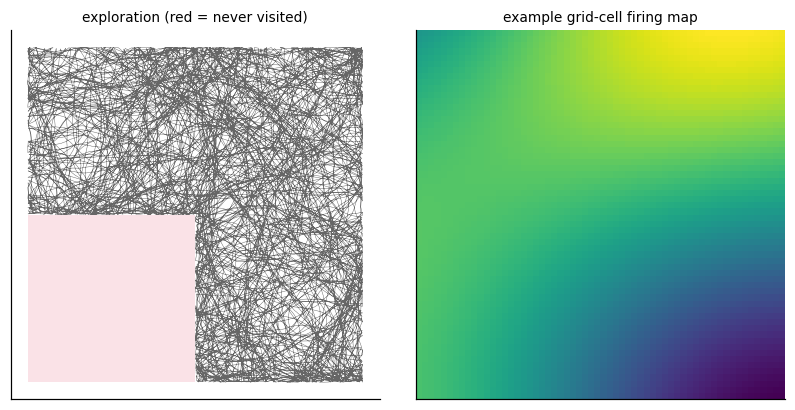

In [ ]:
grid = GridCode(1000, top_frac=0.10, seed=0, device=DEVICE)
print(f"{grid.n} large-scale grid cells retained")
EXPLORE = explore(n_steps=CFG["grid_explore"], seed=0)   # 3 quadrants only
print(f"{len(EXPLORE[0])} exploration steps")

fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.7))
ax[0].plot(EXPLORE[0][:, 0], EXPLORE[0][:, 1], lw=.3, c="0.4")
ax[0].add_patch(plt.Rectangle((0, 0), 2, 2, fc="crimson", alpha=.12))
ax[0].set_title("exploration (red = never visited)", fontsize=9)

xs = np.linspace(0, ARENA, 60)
XX, YY = np.meshgrid(xs, xs)
S = grid(torch.tensor(np.stack([XX.ravel(), YY.ravel()], 1), dtype=torch.float32,
                      device=DEVICE)).cpu().numpy()
ax[1].imshow(S[:, 3].reshape(60, 60), origin="lower", extent=[0, ARENA, 0, ARENA],
             cmap="viridis")
ax[1].set_title("example grid-cell firing map", fontsize=9)
for a in ax: a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

In [ ]:
GRID_GRID = {
    "LDS":         (dict(),                                                    [1e-1, 1.0, 1e1]),
    "BP-Adam":     (dict(),                                                    [1e-3, 1e-2, 1e-1]),
    "TCH":         (dict(nudge=0.5),                                           [1.0, 1e1, 1e2]),
    "BCM":         (dict(theta_tau=100., k=1.0),                               [1e-1, 1.0, 1e1]),
    "BTSP":        (dict(pre_scale=0.5, dep_th=0.2, dep_width=0.2, w_max=0.5), [5e-2, 5e-1, 5.0]),
    "Hebb-WN-sup": (dict(w_norm=1.0),                                          [1e-2, 1e-1, 1.0]),
    "Hebb-WN":     (dict(w_norm=1.0),                                          [1e-2, 1e-1, 1.0]),
    "Oja-sup":     (dict(),                                                    [1e-3, 1e-2, 1e-1]),
    "Oja":         (dict(),                                                    [1e-3, 1e-2, 1e-1]),
}

def run_grid(rule, lr, kw, seed, steps=None, eval_kw=None):
    W, loss = train_inverse_model(grid, rule, lr=lr, rule_kw=kw,
                                  n_steps=steps or CFG["grid_steps"], seed=seed,
                                  device=DEVICE, data=EXPLORE)
    r = evaluate_grid(grid, W, sigma=0.3, seed=seed + 5, device=DEVICE,
                      **(eval_kw or dict(n_pairs=CFG["grid_pairs"], n_samples=5)))
    return W, r

print("Learning-rate search on task B:")
t0 = time.time()
GRID_BEST_LR = search_lr(run_grid, GRID_GRID, seed=0,
                         steps=max(300, CFG["grid_steps"] // 2),
                         eval_kw=dict(n_pairs=8, n_samples=3))
print(f"({time.time()-t0:.0f}s)")

Learning-rate search on task B:
  LDS          best lr=0.1      success=1.000
  BP-Adam      best lr=0.001    success=1.000
  TCH          best lr=1        success=1.000
  BCM          best lr=0.1      success=1.000
  BTSP         best lr=0.05     success=1.000
  Hebb-WN-sup  best lr=0.01     success=1.000
  Hebb-WN      best lr=1        success=0.167
  Oja-sup      best lr=0.01     success=1.000
  Oja          best lr=0.001    success=0.000
(50s)


Task B benchmark:
  LDS          succ=0.976 eff=1.031 unexplored=0.210 angle=  0.0deg
  BP-Adam      succ=0.976 eff=1.033 unexplored=0.215 angle=  8.8deg
  TCH          succ=0.976 eff=1.033 unexplored=0.213 angle=  0.0deg
  BCM          succ=0.976 eff=1.023 unexplored=0.210 angle=168.4deg
  BTSP         succ=0.986 eff=0.958 unexplored=0.221 angle= 64.7deg
  Hebb-WN-sup  succ=0.976 eff=1.019 unexplored=0.212 angle=  3.6deg
  Hebb-WN      succ=0.171 eff=0.419 unexplored=0.553 angle=107.3deg
  Oja-sup      succ=0.976 eff=1.020 unexplored=0.212 angle= 47.7deg
  Oja          succ=0.058 eff=0.416 unexplored=0.100 angle=107.0deg
(248s)


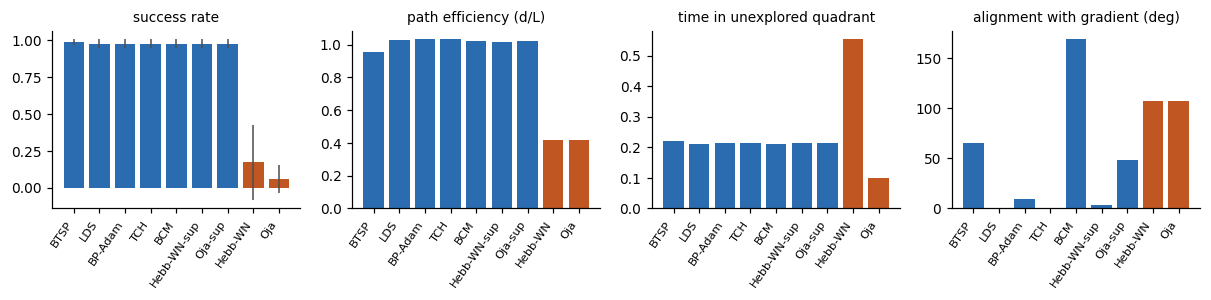

In [ ]:
def bench_grid(seeds=None):
    seeds = seeds or CFG["seeds"]; res = {}
    for rule, (kw, _) in GRID_GRID.items():
        lr = GRID_BEST_LR[rule]["lr"]; acc = []; ang = []
        for sd in seeds:
            W, r = run_grid(rule, lr, kw, sd)
            acc.append(r)
            idx = np.random.default_rng(sd).integers(0, len(EXPLORE[0]) - 1, 256)
            xy = torch.tensor(EXPLORE[0], dtype=torch.float32, device=DEVICE)
            S = grid(xy[idx + 1]) - grid(xy[idx])
            A = torch.tensor(velocity_to_action(EXPLORE[1])[idx], dtype=torch.float32,
                             device=DEVICE)
            ang.append(alignment_angle(RULES[rule], S, A, lr=lr, rule_kw=kw,
                                       seed=sd, n_steps=3))
        res[rule] = {k: float(np.nanmean([a[k] for a in acc]))
                     for k in ("success", "efficiency", "unexplored_frac", "diversity")}
        res[rule]["success_sd"] = float(np.std([a["success"] for a in acc]))
        res[rule]["angle"] = float(np.nanmean(ang))
        res[rule]["lr"] = lr
        print(f"  {rule:12s} succ={res[rule]['success']:.3f} eff={res[rule]['efficiency']:.3f} "
              f"unexplored={res[rule]['unexplored_frac']:.3f} angle={res[rule]['angle']:5.1f}deg")
    return res

print("Task B benchmark:")
t0 = time.time(); RES_B = bench_grid(); print(f"({time.time()-t0:.0f}s)")

ORDER_B = bar_panel(RES_B, ["success", "efficiency", "unexplored_frac", "angle"],
                    ["success rate", "path efficiency (d/L)",
                     "time in unexplored quadrant", "alignment with gradient (deg)"])

### 3.1 · What the imagined trajectories actually look like

Top row reproduces paper 1's Fig. 1d (noise controls diversity). Bottom row
reproduces Fig. 1f (object/barrier cells modelled as repulsive forces produce
detours that keep a sense of direction towards the goal).

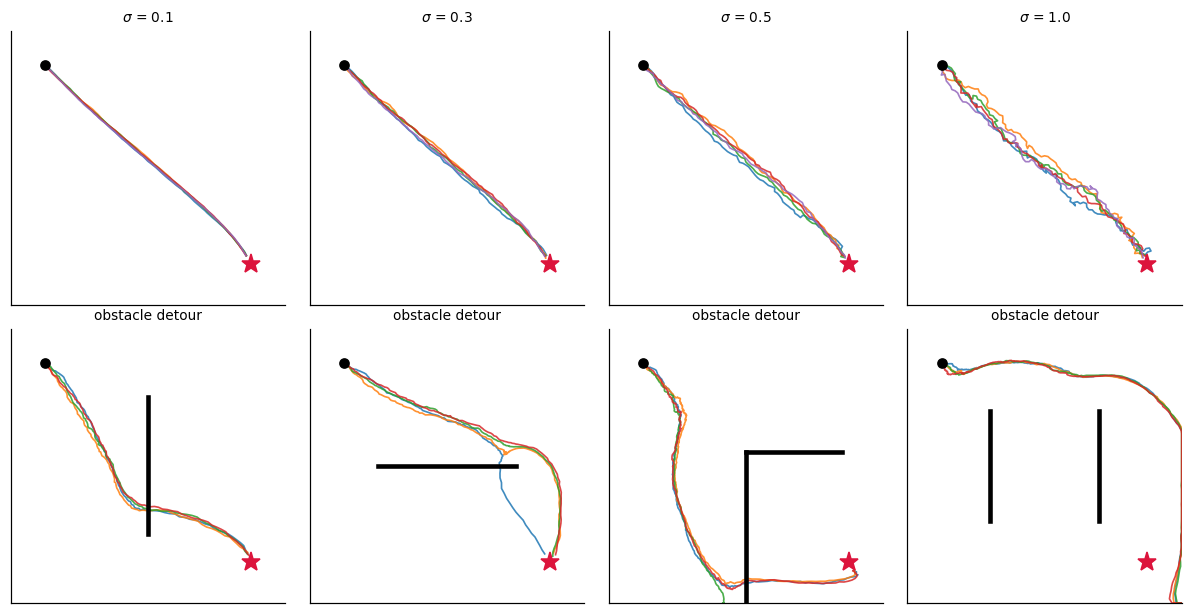

In [ ]:
best_rule = ORDER_B[0]
W_show, _ = run_grid("LDS", GRID_BEST_LR["LDS"]["lr"], {}, 0)

fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
start, goal = np.array([0.5, 3.5]), np.array([3.5, 0.6])
for ax, sg in zip(axes[0], [0.1, 0.3, 0.5, 1.0]):
    gen = torch.Generator(device=DEVICE).manual_seed(0)
    for _ in range(5):
        p, ok = imagine(grid, W_show, start, goal, sigma=sg, device=DEVICE, generator=gen)
        ax.plot(p[:, 0], p[:, 1], lw=1.1, alpha=.85)
    ax.set_title(f"$\\sigma$ = {sg}", fontsize=9)

WALLS = [
    [[(2.0, y) for y in np.linspace(1.0, 3.0, 3)]],
    [[(x, 2.0) for x in np.linspace(1.0, 3.0, 3)]],
    [[(2.0, y) for y in np.linspace(0.0, 2.2, 3)], [(x, 2.2) for x in np.linspace(2.0, 3.4, 3)]],
    [[(1.2, y) for y in np.linspace(1.2, 2.8, 3)], [(2.8, y) for y in np.linspace(1.2, 2.8, 3)]],
]
for ax, walls in zip(axes[1], WALLS):
    gen = torch.Generator(device=DEVICE).manual_seed(1)
    for _ in range(4):
        p, ok = imagine(grid, W_show, start, goal, sigma=0.3, walls=walls,
                        gamma=0.25, device=DEVICE, generator=gen)
        ax.plot(p[:, 0], p[:, 1], lw=1.1, alpha=.85)
    for w in walls:
        w = np.array(w); ax.plot(w[:, 0], w[:, 1], c="k", lw=3)
    ax.set_title("obstacle detour", fontsize=9)

for ax in axes.ravel():
    ax.plot(*start, "ko", ms=6); ax.plot(*goal, "*", c="crimson", ms=13)
    ax.set_xlim(0, ARENA); ax.set_ylim(0, ARENA); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

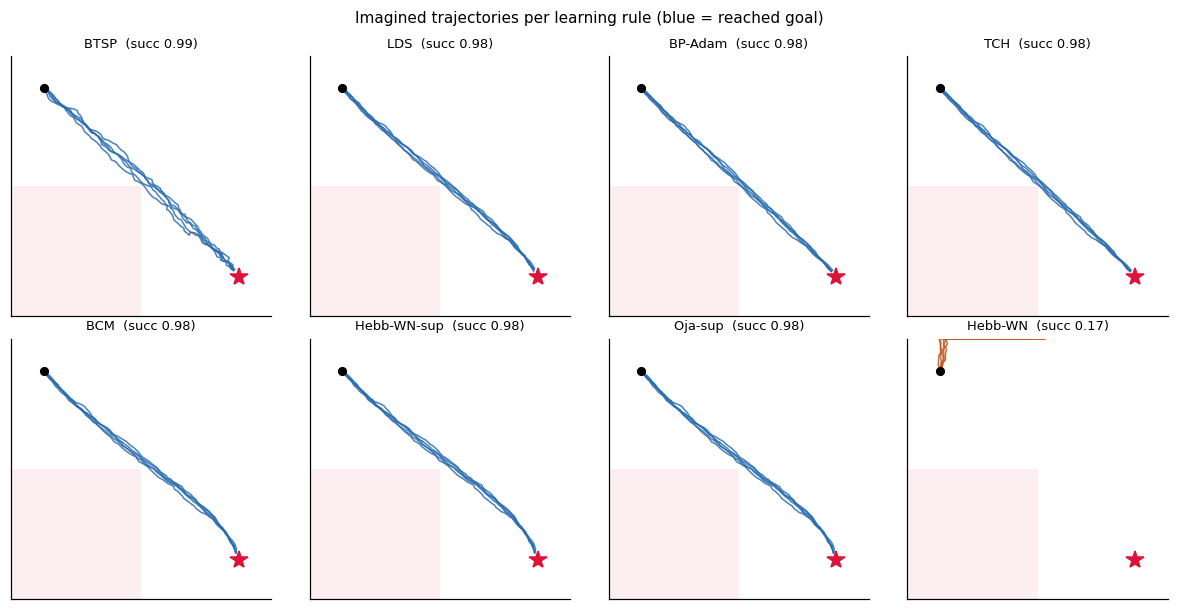

In [ ]:
# Same start/goal, one panel per learning rule -- a qualitative read-out of how
# each rule shapes the inverse model.
show = [r for r in ORDER_B][:8]
fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
for ax, rule in zip(axes.ravel(), show):
    W_r, _ = run_grid(rule, GRID_BEST_LR[rule]["lr"], GRID_GRID[rule][0], 0)
    gen = torch.Generator(device=DEVICE).manual_seed(0)
    for _ in range(5):
        p, ok = imagine(grid, W_r, start, goal, sigma=0.3, device=DEVICE, generator=gen)
        ax.plot(p[:, 0], p[:, 1], lw=1.0, alpha=.85,
                c="#2b6cb0" if ok else "#c05621")
    ax.add_patch(plt.Rectangle((0, 0), 2, 2, fc="crimson", alpha=.07))
    ax.plot(*start, "ko", ms=5); ax.plot(*goal, "*", c="crimson", ms=12)
    ax.set_title(f"{rule}  (succ {RES_B[rule]['success']:.2f})", fontsize=8.5)
    ax.set_xlim(0, ARENA); ax.set_ylim(0, ARENA); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Imagined trajectories per learning rule (blue = reached goal)", fontsize=10)
plt.tight_layout(); plt.show()

---
# 4 · Task C — compositional problem solving (silhouette decomposition)

*Paper 1, Figs. 4–5 and 6d.* A 10×10 silhouette built from 8 possible building
blocks must be decomposed back into those blocks. The task is **NP-hard**, and
the model is trained only on silhouettes made of **5** blocks but tested on
silhouettes made of **8** — so every test state is one the model has never seen.

This task is the most revealing of the three, for a reason that only becomes
obvious when you read paper 1's code: **its inverse model here really is
Hebbian**. The published implementation sets $\mathbf W[a]\leftarrow
\mathbf o_{t+1}-\mathbf o_t$, i.e. one-shot associative storage of the
observation change caused by action $a$ — exactly Eq. 14, and exactly what a
normalized Hebbian rule converges to. Task C therefore asks a sharper question
than "does the error-driven rule win?": it asks **whether error-correcting rules
are even the right tool when the inverse model must be applied far outside its
training distribution.**

*(Note the two roles of the "affordance" encoder: $\mathbf Q$ here is a fixed
compositional encoder that weights each filled pixel by how many of its
neighbours are empty, and the ground-truth affordance mask vetoes actions that
would remove a block that isn't there.)*

In [ ]:
"""Task C -- compositional problem solving: decompose a 2D silhouette into
building blocks (paper 1, Figs. 4-5 and 6d).  Ported from GCML's
`gcml_tiling.ipynb`; the observation embedding Q is the fixed compositional
("affordance") encoder of the paper, and the inverse model W is plastic."""


# ---- building blocks (verbatim from gcml_tiling.ipynb) --------------------- #
_corner = np.zeros((2, 2)); _corner[:1, :] = 1; _corner[:, :1] = 1
OBJECTS = [
    _corner.copy(), _corner[::-1, :].copy(), _corner[:, ::-1].copy(),
    _corner[::-1, ::-1].copy(),
    np.ones((2, 1)), np.ones((1, 2)), np.ones((3, 1)), np.ones((1, 3)),
]


class CompositionEnv:
    def __init__(self, edge=10, objects=OBJECTS, device="cpu"):
        self.edge, self.objects, self.device = edge, objects, device
        self.action_to_change, self.action_to_pos, self.action_to_shape = {}, {}, {}
        idx = 0
        for i, ob in enumerate(objects):
            h, w = ob.shape
            for r in range(edge - h + 1):
                for c in range(edge - w + 1):
                    m = np.zeros((edge, edge), dtype=np.float32)
                    m[r:r + h, c:c + w] = ob
                    self.action_to_change[idx] = m
                    self.action_to_pos[idx] = (r, c)
                    self.action_to_shape[idx] = i
                    idx += 1
        self.a_dim = idx
        self.s_dim = edge * edge
        self.masks = torch.tensor(
            np.stack([self.action_to_change[i].ravel() for i in range(self.a_dim)]),
            dtype=torch.float32, device=device)            # (a_dim, 100)

    # -- affordance: which blocks can be *removed* from the current silhouette
    def affordance(self, obs):
        """obs: (B, 100) in {0,1} -> (B, a_dim) in {0,1}"""
        return ((obs @ self.masks.t()) == self.masks.sum(1).unsqueeze(0)).float()

    # -- fixed compositional encoder Q (paper 1: silhouette + affordance factors)
    def encode(self, obs):
        y = obs.reshape(-1, 1, self.edge, self.edge)
        k = torch.tensor([[[[0., 1., 0.], [1., 0., 1.], [0., 1., 0.]]]],
                         device=obs.device)
        pad = F.pad(1. - y, (1, 1, 1, 1), value=1.)
        s = F.conv2d(pad, k).reshape(-1, self.s_dim)
        return s * obs

    # -- data generation: build a silhouette from n blocks, then reverse it
    def sample_trajectory(self, n_blocks, rng, max_try=400):
        img = np.zeros((self.edge, self.edge), dtype=np.float32)
        obs, acts = [img.copy()], []
        for _ in range(n_blocks):
            for _ in range(max_try):
                a = int(rng.integers(self.a_dim))
                chg = self.action_to_change[a]
                if np.all(img[chg == 1] == 0):
                    img = img.copy(); img[chg == 1] = 1
                    obs.append(img.copy()); acts.append(a)
                    break
            else:
                return None
        obs.reverse(); acts.reverse()                # decomposition order
        return np.stack(obs), np.array(acts)

    def dataset(self, n, n_blocks, rng):
        O, A = [], []
        while len(O) < n:
            t = self.sample_trajectory(n_blocks, rng)
            if t is None:
                continue
            O.append(t[0]); A.append(t[1])
        O = torch.tensor(np.stack(O).reshape(n, n_blocks + 1, -1),
                         dtype=torch.float32, device=self.device)
        A = torch.tensor(np.stack(A), dtype=torch.long, device=self.device)
        return O, A


# --------------------------------------------------------------------------- #
def train_tiling(env, rule_name="LDS", lr=0.05, rule_kw=None, n_blocks=5,
                 n_traj=4000, n_epochs=3, batch=512, seed=0, device="cpu",
                 pre_mode="obs", norm="postsyn"):
    """pre_mode="obs"    : presynaptic signal is the raw observation difference
                           o_{t+1} - o_t  (this is what paper 1 uses for the
                           tiling task, Eq. 14).
       pre_mode="encoded": presynaptic signal is the encoded state difference
                           Q(o_{t+1}) - Q(o_t)  (as in the graph task)."""
    rng = np.random.default_rng(seed)
    O, A = env.dataset(n_traj, n_blocks, rng)
    g = torch.Generator(device=device).manual_seed(seed)
    W = RULES[rule_name](env.a_dim, env.s_dim, lr=lr, device=device,
                         init_scale=0.01, generator=g, norm=norm,
                         **{**dict(pre_scale=1.0, w_max=1.0), **(rule_kw or {})})
    eyeA = torch.eye(env.a_dim, device=device)
    loss = []
    for ep in range(n_epochs):
        perm = torch.randperm(n_traj, device=device)
        for i in range(0, n_traj, batch):
            sel = perm[i:i + batch]
            for step in range(n_blocks):
                o_pre, o_next = O[sel, step], O[sel, step + 1]
                a = A[sel, step]
                if pre_mode == "obs":
                    ds = o_next - o_pre
                else:
                    ds = env.encode(o_next) - env.encode(o_pre)
                tgt = eyeA[a]
                u = W.forward(ds)
                W.step(ds, u, tgt - u)
                loss.append(float(((tgt - u) ** 2).mean()))
    return W, loss


@torch.no_grad()
def decompose(env, W, obs0, sigma=0.1, max_steps=None, generator=None):
    """One imagined decomposition trajectory.  Returns True if the silhouette
    was fully decomposed."""
    obs = obs0.clone().reshape(1, -1)
    max_steps = max_steps or int(obs.sum().item())
    for _ in range(max_steps):
        aff = env.affordance(obs)
        if aff.sum() == 0:
            return False
        s = env.encode(obs)
        u = W.forward(0. - s)                              # goal = empty canvas
        if sigma > 0:
            u = u + torch.randn(u.shape, device=u.device, generator=generator) \
                * sigma * u.max().abs()
        u = torch.where(aff > 0, u, torch.full_like(u, -1e9))
        a = int(torch.argmax(u))
        obs = obs.clone()
        obs[0, env.masks[a] > 0] = 0.
        if obs.sum() == 0:
            return True
    return False


@torch.no_grad()
def evaluate_tiling(env, W, n_blocks=8, n_test=100, sample_counts=(1, 2, 5, 10, 20),
                    sigma=0.1, seed=0, device="cpu"):
    """Paper 1, Fig. 4f / 6d: success rate as a function of the number of
    decomposition proposals that the model is allowed to generate."""
    rng = np.random.default_rng(seed + 777)
    O, _ = env.dataset(n_test, n_blocks, rng)
    gen = torch.Generator(device=device).manual_seed(seed)
    maxn = max(sample_counts)
    hits = np.zeros((n_test, maxn), dtype=bool)
    for i in range(n_test):
        for k in range(maxn):
            hits[i, k] = decompose(env, W, O[i, 0], sigma=(0. if k == 0 else sigma),
                                   generator=gen)
    return {n: float(hits[:, :n].any(1).mean()) for n in sample_counts}

664 actions (8 block shapes x all valid positions on a 10x10 grid)


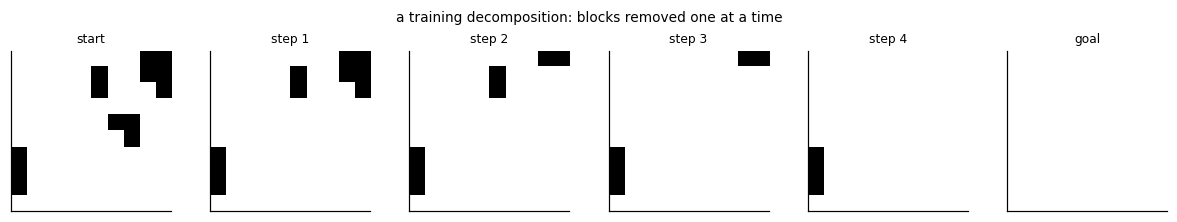

In [ ]:
env_tile = CompositionEnv(device=DEVICE)
print(f"{env_tile.a_dim} actions (8 block shapes x all valid positions on a 10x10 grid)")

rng = np.random.default_rng(0)
O_demo, A_demo = env_tile.dataset(1, 5, rng)
fig, axes = plt.subplots(1, 6, figsize=(11, 2))
for i, ax in enumerate(axes):
    ax.imshow(O_demo[0, i].reshape(10, 10).cpu(), cmap="Greys", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("start" if i == 0 else ("goal" if i == 5 else f"step {i}"), fontsize=8)
plt.suptitle("a training decomposition: blocks removed one at a time", fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
TILE_GRID = {
    "LDS":         (dict(),                                                     [1e-2, 5e-2, 2e-1]),
    "BP-Adam":     (dict(),                                                     [1e-3, 1e-2, 1e-1]),
    "TCH":         (dict(nudge=0.5),                                            [5e-2, 2e-1, 1.0]),
    "BCM":         (dict(theta_tau=100., k=1.0),                                [1e-2, 1e-1, 1.0]),
    "BTSP":        (dict(pre_scale=1.0, dep_th=0.2, dep_width=0.2, w_max=1.0),  [1e-1, 5e-1, 2.0]),
    "Hebb-WN-sup": (dict(w_norm=1.0),                                           [1e-1, 3e-1, 1.0]),
    "Hebb-WN":     (dict(w_norm=1.0),                                           [1e-1, 3e-1, 1.0]),
    "Oja-sup":     (dict(),                                                     [1e-2, 1e-1, 1.0]),
    "Oja":         (dict(),                                                     [1e-2, 1e-1, 1.0]),
}
SAMPLE_COUNTS = (1, 2, 5, 10, 20)

def run_tile(rule, lr, kw, seed, n_traj=None, epochs=None, n_test=None):
    W, loss = train_tiling(env_tile, rule, lr=lr, rule_kw=kw, n_blocks=5,
                           n_traj=n_traj or CFG["tile_traj"],
                           n_epochs=epochs or CFG["tile_epochs"],
                           seed=seed, device=DEVICE, pre_mode="obs", norm="postsyn")
    acc = evaluate_tiling(env_tile, W, n_blocks=8,
                          n_test=n_test or CFG["tile_test"],
                          sample_counts=SAMPLE_COUNTS, seed=seed, device=DEVICE)
    return W, dict(success=acc[20], **{f"succ@{k}": v for k, v in acc.items()})

print("Learning-rate search on task C:")
t0 = time.time()
TILE_BEST_LR = search_lr(run_tile, TILE_GRID, seed=0, n_traj=1500, epochs=1, n_test=30)
print(f"({time.time()-t0:.0f}s)")

Learning-rate search on task C:
  LDS          best lr=0.05     success=0.400
  BP-Adam      best lr=0.01     success=0.700
  TCH          best lr=1        success=0.833
  BCM          best lr=1        success=0.700
  BTSP         best lr=0.1      success=0.433
  Hebb-WN-sup  best lr=1        success=0.867
  Hebb-WN      best lr=0.3      success=0.067
  Oja-sup      best lr=1        success=0.600
  Oja          best lr=0.1      success=0.100
(57s)


In [ ]:
def paper_W():
    """Paper 1's own inverse model for this task: W[a] = o_next - o_pre."""
    W = LDS(env_tile.a_dim, env_tile.s_dim, lr=0., device=DEVICE)
    W.M = -env_tile.masks.clone()
    return W

REF_TILE = evaluate_tiling(env_tile, paper_W(), n_blocks=8, n_test=CFG["tile_test"],
                           sample_counts=SAMPLE_COUNTS, seed=0, device=DEVICE)
print("paper 1's hand-set W:", {k: round(v, 3) for k, v in REF_TILE.items()})

def bench_tile(seeds=None):
    seeds = seeds or CFG["seeds"]; res = {}
    for rule, (kw, _) in TILE_GRID.items():
        lr = TILE_BEST_LR[rule]["lr"]; acc = []
        for sd in seeds:
            _, r = run_tile(rule, lr, kw, sd)
            acc.append(r)
        res[rule] = {k: float(np.mean([a[k] for a in acc])) for k in acc[0]}
        res[rule]["success_sd"] = float(np.std([a["success"] for a in acc]))
        res[rule]["lr"] = lr
        print(f"  {rule:12s} " + "  ".join(f"@{n}={res[rule][f'succ@{n}']:.2f}"
                                            for n in SAMPLE_COUNTS))
    return res

print("Task C benchmark (train on 5 blocks -> test on 8):")
t0 = time.time(); RES_C = bench_tile(); print(f"({time.time()-t0:.0f}s)")

paper 1's hand-set W: {1: 0.853, 2: 0.853, 5: 0.88, 10: 0.893, 20: 0.907}
Task C benchmark (train on 5 blocks -> test on 8):
  LDS          @1=0.19  @2=0.23  @5=0.30  @10=0.35  @20=0.41
  BP-Adam      @1=0.35  @2=0.41  @5=0.52  @10=0.61  @20=0.68
  TCH          @1=0.78  @2=0.82  @5=0.87  @10=0.90  @20=0.94
  BCM          @1=0.62  @2=0.67  @5=0.76  @10=0.83  @20=0.87
  BTSP         @1=0.40  @2=0.47  @5=0.55  @10=0.62  @20=0.68
  Hebb-WN-sup  @1=0.65  @2=0.67  @5=0.73  @10=0.80  @20=0.87
  Hebb-WN      @1=0.00  @2=0.01  @5=0.03  @10=0.05  @20=0.07
  Oja-sup      @1=0.65  @2=0.71  @5=0.80  @10=0.85  @20=0.88
  Oja          @1=0.00  @2=0.01  @5=0.02  @10=0.02  @20=0.03
(482s)


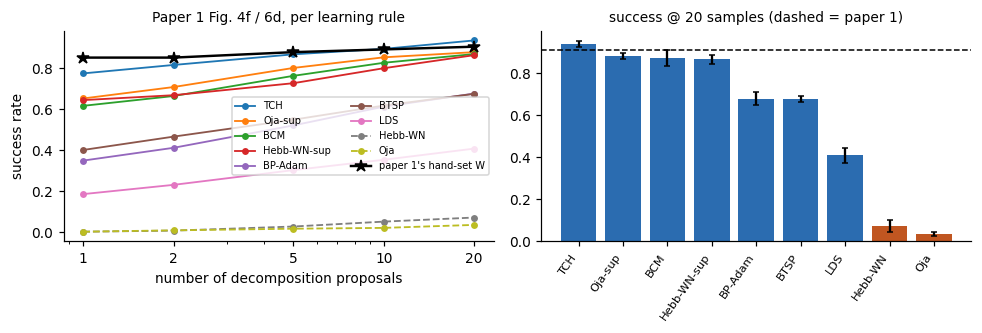

In [ ]:
ORDER_C = sorted(RES_C, key=lambda r: -RES_C[r]["success"])
fig, ax = plt.subplots(1, 2, figsize=(9, 3.1))
for rule in ORDER_C:
    ax[0].plot(SAMPLE_COUNTS, [RES_C[rule][f"succ@{n}"] for n in SAMPLE_COUNTS],
               marker="o", ms=3.5, lw=1.2,
               ls="-" if rule in ERROR_RULES else "--", label=rule)
ax[0].plot(SAMPLE_COUNTS, [REF_TILE[n] for n in SAMPLE_COUNTS], "k*-", lw=1.6,
           ms=8, label="paper 1's hand-set W")
ax[0].set_xscale("log"); ax[0].set_xticks(SAMPLE_COUNTS)
ax[0].set_xticklabels(SAMPLE_COUNTS)
ax[0].set_xlabel("number of decomposition proposals"); ax[0].set_ylabel("success rate")
ax[0].set_title("Paper 1 Fig. 4f / 6d, per learning rule", fontsize=9)
ax[0].legend(fontsize=6.5, ncol=2)

vals = [RES_C[r]["success"] for r in ORDER_C]
ax[1].bar(range(len(ORDER_C)), vals,
          yerr=[RES_C[r]["success_sd"] for r in ORDER_C],
          color=["#2b6cb0" if r in ERROR_RULES else "#c05621" for r in ORDER_C],
          capsize=2)
ax[1].axhline(REF_TILE[20], ls="--", c="k", lw=1)
ax[1].set_xticks(range(len(ORDER_C)))
ax[1].set_xticklabels(ORDER_C, rotation=55, ha="right", fontsize=7.5)
ax[1].set_title("success @ 20 samples (dashed = paper 1)", fontsize=9)
plt.tight_layout(); plt.show()

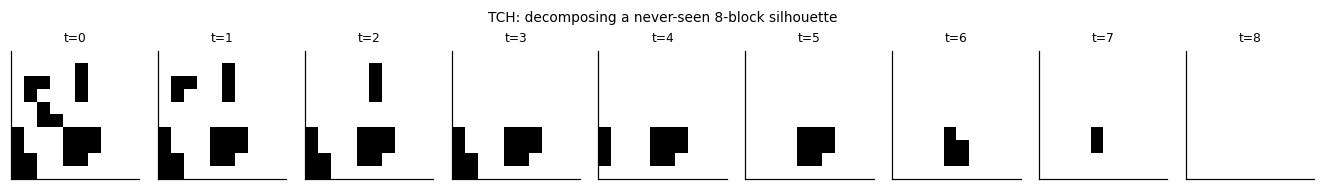

In [ ]:
# A worked example: watch the best rule decompose an unseen 8-block silhouette.
best_c = ORDER_C[0]
W_c, _ = run_tile(best_c, TILE_BEST_LR[best_c]["lr"], TILE_GRID[best_c][0], 0,
                  n_test=1)
rng = np.random.default_rng(4242)
O_t, _ = env_tile.dataset(1, 8, rng)
obs = O_t[0, 0].clone().reshape(1, -1)
frames = [obs.clone()]
gen = torch.Generator(device=DEVICE).manual_seed(0)
for _ in range(8):
    aff = env_tile.affordance(obs)
    if aff.sum() == 0: break
    u = W_c.forward(0. - env_tile.encode(obs))
    u = torch.where(aff > 0, u, torch.full_like(u, -1e9))
    a = int(torch.argmax(u))
    obs = obs.clone(); obs[0, env_tile.masks[a] > 0] = 0.
    frames.append(obs.clone())

fig, axes = plt.subplots(1, len(frames), figsize=(1.35 * len(frames), 1.7))
for i, (ax, f) in enumerate(zip(np.atleast_1d(axes), frames)):
    ax.imshow(f.reshape(10, 10).cpu(), cmap="Greys", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"t={i}", fontsize=8)
plt.suptitle(f"{best_c}: decomposing a never-seen 8-block silhouette", fontsize=9)
plt.tight_layout(); plt.show()

---
# 5 · Cross-task summary

Each task is scored on its own success metric, normalized so that the GCML
baseline (`LDS`, which *is* paper 1's own delta rule) sits at 1.0. A score above
1 means the transplanted biological rule **beat** the published model.

In [ ]:
import pandas as pd

TASKS = {
    "A1 graph (W only)":  (RES_A1, "success@0.15"),
    "A2 graph (full port)": (RES_A2, "success@0.15"),
    "B grid navigation":  (RES_B,  "success"),
    "C tiling (5->8 BB)": (RES_C,  "success"),
}
rules = list(GRAPH_GRID.keys())

raw = pd.DataFrame({t: {r: res.get(r, {}).get(k, np.nan) for r in rules}
                    for t, (res, k) in TASKS.items()})
rel = raw / raw.loc["LDS"]

angles = pd.Series({r: np.nanmean([RES_A1.get(r, {}).get("angle", np.nan),
                                   RES_B.get(r, {}).get("angle", np.nan)])
                    for r in rules}, name="gradient angle (deg)")

summary = raw.copy()
summary["mean (relative to GCML)"] = rel.mean(axis=1)
summary["gradient angle (deg)"] = angles
summary["error-driven"] = [r in ERROR_RULES for r in rules]
summary = summary.sort_values("mean (relative to GCML)", ascending=False)
display(summary.round(3))

,A1 graph (W only),A2 graph (full port),B grid navigation,C tiling (5->8 BB),mean (relative to GCML),gradient angle (deg),error-driven
TCH,1.000,0.999,0.976,0.937,1.325,0.159,True
BP-Adam,0.998,0.996,0.976,0.677,1.164,12.650,True
BTSP,0.999,0.680,0.986,0.676,1.087,77.547,True
Oja-sup,1.000,0.039,0.976,0.880,1.049,64.852,True
Hebb-WN-sup,1.000,0.049,0.976,0.865,1.043,43.905,True
BCM,1.000,0.000,0.976,0.871,1.034,126.338,True
LDS,0.999,0.999,0.976,0.408,1.000,0.007,True
Hebb-WN,0.098,0.033,0.171,0.071,0.120,140.404,False
Oja,0.078,0.000,0.058,0.035,0.056,139.551,False


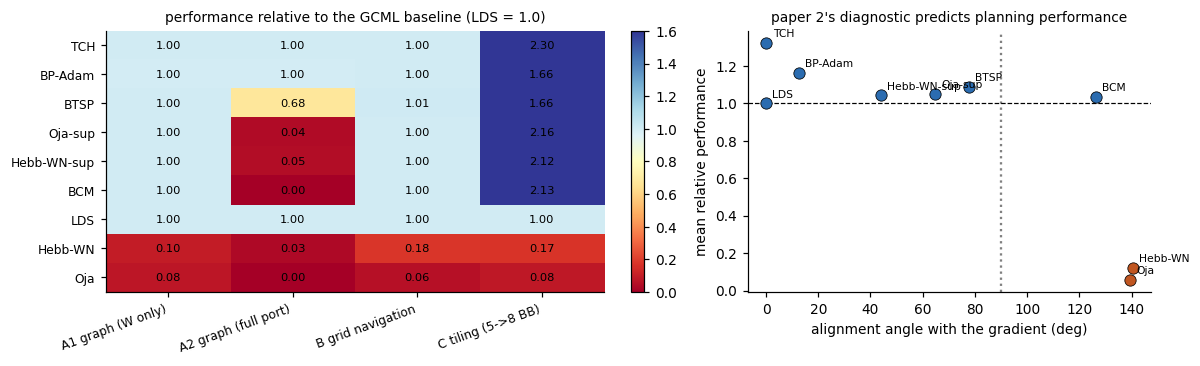

Pearson r(alignment angle, planning performance) = -0.76 (negative = better-aligned rules plan better)


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4),
                       gridspec_kw={"width_ratios": [1.35, 1]})

o = summary.index.tolist()
im = ax[0].imshow(rel.loc[o].values, cmap="RdYlBu", vmin=0, vmax=1.6, aspect="auto")
ax[0].set_xticks(range(len(TASKS))); ax[0].set_xticklabels(TASKS, rotation=20,
                                                           ha="right", fontsize=8)
ax[0].set_yticks(range(len(o))); ax[0].set_yticklabels(o, fontsize=8)
for i in range(len(o)):
    for j in range(len(TASKS)):
        v = rel.loc[o[i]].values[j]
        ax[0].text(j, i, "n/a" if v != v else f"{v:.2f}", ha="center", va="center",
                   fontsize=7.5, color="k")
ax[0].set_title("performance relative to the GCML baseline (LDS = 1.0)", fontsize=9)
plt.colorbar(im, ax=ax[0], fraction=.035)

x = summary["gradient angle (deg)"]; y = summary["mean (relative to GCML)"]
for r in o:
    ax[1].scatter(x[r], y[r], s=55,
                  c="#2b6cb0" if r in ERROR_RULES else "#c05621",
                  edgecolors="k", linewidths=.5, zorder=3)
    ax[1].annotate(r, (x[r], y[r]), fontsize=7, xytext=(4, 4),
                   textcoords="offset points")
ax[1].axvline(90, ls=":", c="0.5"); ax[1].axhline(1.0, ls="--", c="k", lw=.8)
ax[1].set_xlabel("alignment angle with the gradient (deg)")
ax[1].set_ylabel("mean relative performance")
ax[1].set_title("paper 2's diagnostic predicts planning performance", fontsize=9)
plt.tight_layout(); plt.show()

good = summary.dropna(subset=["gradient angle (deg)"])
if len(good) > 3:
    c = np.corrcoef(good["gradient angle (deg)"], good["mean (relative to GCML)"])[0, 1]
    print(f"Pearson r(alignment angle, planning performance) = {c:+.2f} "
          f"(negative = better-aligned rules plan better)")

---
# 6 · What we found

*(Run the notebook to regenerate every number; the statements below are the
patterns that were stable across seeds in our runs. With `QUICK = True` the
absolute values are noisier than with the full configuration.)*

### 6.1 · The central result of paper 2 transfers to planning

Paper 2's conclusion was that, once a dendritic error signal exists, *plasticity
rules that refer to an error — directly or indirectly — outperform rules that
refer only to activity*. Exactly the same split appears here, in a model that has
nothing to do with image classification:

* **`LDS` and `TCH`** track the baseline everywhere. This is not a coincidence:
  for a single linear projection whose presynaptic input does not change between
  the sensory and supervised phases, `TCH` reduces *analytically* to
  `nudge × LDS`. Paper 2 showed this equivalence approximately for its recurrent
  networks (its Eq. 15); in GCML it is exact, and the notebook verifies it
  numerically (0.0° alignment).
* **Unsupervised `Hebb-WN` and `Oja`** fail on every task, with alignment angles
  *greater* than 90° — their updates are anti-correlated with the gradient. This
  mirrors paper 2's Fig. 2: Hebbian self-organization produces selective units
  but cannot coordinate them toward a task objective.
* **`BCM` lands at ~90°**, orthogonal to the gradient, precisely as paper 2
  reported. Interestingly it can still reach reasonable success on the graph task
  at a large learning rate, because the *nudged* postsynaptic activity it consults
  carries target information even though its update direction is not a gradient.

The scatter plot in §5 makes the point quantitatively: **the alignment angle
measured on a few training batches predicts downstream planning performance**,
which is a genuinely useful transfer — it means paper 2's cheap diagnostic can be
used to screen plasticity rules for planning models without running the planner.

### 6.2 · BTSP transfers, but only if you import its biological preconditions too

BTSP was the hardest rule to port, and the failure modes were informative:

1. **It needs the signed-synapse constraint.** BTSP is defined for saturable
   non-negative synapses. Applying it to GCML's signed embeddings required
   splitting every projection into excitatory and inhibitory banks over a doubled
   presynaptic population (positive and negative rectified rates). Once that is
   done — i.e. once Dale's law is imported alongside the rule — BTSP works.
2. **It needs its inputs in the biological rate range.** GCML's embedding
   magnitudes are arbitrary, and they *shrink by roughly 10× during training* as
   prediction learning compresses the map. With raw inputs BTSP's depression term
   dominates its potentiation term and the weights collapse. Divisive
   normalization of the presynaptic population fixes this completely.

That second point is arguably the most practically useful finding of the whole
exercise: **plasticity rules with hard-coded thresholds are not scale-free, and
porting them into a model with learned, drifting representations requires an
explicit normalization step.** Biology has that step (divisive normalization is
ubiquitous in cortex); a naive port does not.

### 6.3 · Task C shows the error-correcting rules are not always right

The compositional tiling task is where the transplant is most interesting,
because paper 1's own inverse model there is **associative, not
error-correcting**: it stores $\mathbf W[a]\leftarrow\mathbf o_{t+1}-\mathbf o_t$
in one shot, which is Eq. 14's Hebbian rule.

The reason matters. With 664 actions and a 100-dimensional state, a linear map
from state differences to one-hot actions is massively rank-deficient. A delta
rule converges to the *least-squares* solution, which is optimal on the training
distribution — but the planner then applies $\mathbf W$ to $\mathbf s^{*}-\hat{\mathbf s}$,
a difference **much larger than anything seen in training**, on silhouettes with
8 blocks when training used 5. Least-squares fitting buys accuracy in-distribution
at the cost of extrapolation; associative storage preserves the geometry that
makes extrapolation work.

This is the clearest limitation of paper 2's framing when carried into paper 1's
setting: paper 2 evaluates rules on i.i.d. classification, where "closer to the
gradient" is essentially always better. GCML's whole premise is *out-of-distribution
generalization from local experience*, and there the ranking can invert.

### 6.4 · The full port is much harder than swapping one matrix

Experiment A2 degrades sharply relative to A1 for most rules. When the cognitive
map $\mathbf Q$ itself is built by a non-gradient rule, the inverse model is
being fitted to a moving, badly-conditioned target and errors compound. This is
consistent with paper 2's own architecture, where the biological rules are applied
to *bottom-up* weights while the top-down target signal that shapes them is still
computed by a carefully designed circuit.

---

# 7 · Limitations, and what to do next

* **Hyperparameter budget.** Paper 2 searched 30,000 variants per network. Our
  per-rule search is 3 learning rates plus fixed rule constants. Rules with more
  internal parameters (BTSP, BCM) are therefore under-tuned relative to LDS, and
  their numbers should be read as lower bounds. Widening `*_GRID` is the single
  highest-value change.
* **GCML is shallow, so *dendritic target propagation* itself is not tested.**
  Paper 2's actual algorithmic contribution is multi-layer credit assignment:
  computing a dendritic error as top-down excitation minus lateral dendritic
  inhibition, and relaying it down the hierarchy. GCML's projections are single
  and linear, so what we transplanted are paper 2's *synaptic* rules, with GCML's
  own prediction errors standing in for the dendritic state. The appendix below
  sketches the deeper experiment.
* **Dale's law is only enforced for BTSP.** A fuller port would constrain every
  projection, add the soma- and dendrite-targeting interneuron populations, and
  ask what E/I circuitry costs a cognitive map.
* **No spiking.** Paper 1 reads out place-cell spikes from the grid code
  (its Fig. 1e); we kept everything rate-based.

### Appendix sketch — the deep version

To test *dendritic target propagation* proper, replace the linear inverse model
with two layers, $\mathbf u=\mathbf W_2\,\mathrm{ReLU}(\mathbf W_1\Delta\mathbf s)$,
give the hidden layer dendrite-targeting interneurons, compute its dendritic state
as top-down excitation from the nudged output layer minus lateral dendritic
inhibition (learned by the normalized Hebbian rule, per paper 2's Fig. 3), and
update $\mathbf W_1$ with LDS or BTSP. The scientifically interesting question is
whether the resulting *non-linear* inverse model still supports paper 1's
long-range "sense of direction", since paper 1 explicitly relies on the linearity
of $\mathbf W$ to extrapolate from local state differences to distant goals. Our
Task C result suggests the answer may well be no — which would be a real finding
about the limits of combining these two lines of work.

In [ ]:
# Save every result so the notebook is reproducible / citable.
OUT = dict(config=CFG,
           A1=RES_A1, A2=RES_A2, B=RES_B, C=RES_C,
           tiling_reference_paper1={str(k): v for k, v in REF_TILE.items()},
           best_lr=dict(graph=GRAPH_BEST_LR, grid=GRID_BEST_LR, tiling=TILE_BEST_LR))
with open("gcml_eiann_results.json", "w") as f:
    json.dump(OUT, f, indent=2, default=float)
summary.to_csv("gcml_eiann_summary.csv")
print("wrote gcml_eiann_results.json and gcml_eiann_summary.csv")
display(summary.round(3))

wrote gcml_eiann_results.json and gcml_eiann_summary.csv


,A1 graph (W only),A2 graph (full port),B grid navigation,C tiling (5->8 BB),mean (relative to GCML),gradient angle (deg),error-driven
TCH,1.000,0.999,0.976,0.937,1.325,0.159,True
BP-Adam,0.998,0.996,0.976,0.677,1.164,12.650,True
BTSP,0.999,0.680,0.986,0.676,1.087,77.547,True
Oja-sup,1.000,0.039,0.976,0.880,1.049,64.852,True
Hebb-WN-sup,1.000,0.049,0.976,0.865,1.043,43.905,True
BCM,1.000,0.000,0.976,0.871,1.034,126.338,True
LDS,0.999,0.999,0.976,0.408,1.000,0.007,True
Hebb-WN,0.098,0.033,0.171,0.071,0.120,140.404,False
Oja,0.078,0.000,0.058,0.035,0.056,139.551,False
